In [34]:
import pandas as pd
import numpy as np

In [35]:
df = pd.read_csv("NIGERIA_WFP_ADMIN1.csv", sep=None, engine="python")
df["time"] = pd.to_datetime(df["time"], errors="coerce", dayfirst=True)
df = df.dropna(subset=["time", "NAME_1"])
df["year"] = df["time"].dt.year

# NDVI: prends celui que tu as (vim)
df["ndvi"] = df["vim"]

# On filtre la qualité NDVI
df = df[df["viq"] >= 80].copy()   

df = df.sort_values(["NAME_1", "time"])
df.head(5)

,time,NAME_1,inadequate,bnds,Y,X,Evap_tavg,LWdown_f_tavg,Lwnet_tavg,Psurf_f_tavg,...,SoilMoi40_100cm_tavg,SoilMoi100_200cm_tavg,SoilTemp00_10cm_tavg,SoilTemp10_40cm_tavg,SoilTemp40_100cm_tavg,SoilTemp100_200cm_tavg,vim,viq,year,ndvi
0,2023-01-01,Abia,0.296774,0.5,5.395,7.471889,0.000016,385.566324,-71.064699,99941.271400,...,0.374807,0.389133,300.138219,299.605325,299.121555,298.700373,0.569790,101.510920,2023,0.569790
28,2023-01-02,Abia,0.401515,0.5,5.395,7.471889,0.000014,392.934595,-69.757725,99864.297600,...,0.365446,0.375858,301.087698,300.549694,300.019129,299.368246,0.598635,100.312830,2023,0.598635
56,2023-01-03,Abia,0.281046,0.5,5.395,7.471889,0.000026,408.719824,-44.999965,99913.329933,...,0.379434,0.378395,299.624543,299.767199,299.874593,299.740318,0.683211,102.223080,2023,0.683211
84,2023-01-04,Abia,0.300613,0.5,5.395,7.471889,0.000030,416.609924,-39.776577,99798.052400,...,0.396723,0.403678,299.950588,299.849166,299.700418,299.525405,0.751135,102.335600,2023,0.751135
112,2023-01-05,Abia,0.226667,0.5,5.395,7.471889,0.000039,419.145751,-35.249339,99990.250067,...,0.413261,0.422155,299.604193,299.639713,299.624382,299.501924,0.790905,102.097565,2023,0.790905


In [36]:
df['Rainf_f_tavg'].mean()

np.float64(4.2265244716173286e-05)

In [37]:
df["month"] = df["time"].astype(str).str.split("-").str[2].astype(int)
df["year"]  = df["time"].astype(str).str.split("-").str[0].astype(int)

df.head(5)

,time,NAME_1,inadequate,bnds,Y,X,Evap_tavg,LWdown_f_tavg,Lwnet_tavg,Psurf_f_tavg,...,SoilMoi100_200cm_tavg,SoilTemp00_10cm_tavg,SoilTemp10_40cm_tavg,SoilTemp40_100cm_tavg,SoilTemp100_200cm_tavg,vim,viq,year,ndvi,month
0,2023-01-01,Abia,0.296774,0.5,5.395,7.471889,0.000016,385.566324,-71.064699,99941.271400,...,0.389133,300.138219,299.605325,299.121555,298.700373,0.569790,101.510920,2023,0.569790,1
28,2023-01-02,Abia,0.401515,0.5,5.395,7.471889,0.000014,392.934595,-69.757725,99864.297600,...,0.375858,301.087698,300.549694,300.019129,299.368246,0.598635,100.312830,2023,0.598635,2
56,2023-01-03,Abia,0.281046,0.5,5.395,7.471889,0.000026,408.719824,-44.999965,99913.329933,...,0.378395,299.624543,299.767199,299.874593,299.740318,0.683211,102.223080,2023,0.683211,3
84,2023-01-04,Abia,0.300613,0.5,5.395,7.471889,0.000030,416.609924,-39.776577,99798.052400,...,0.403678,299.950588,299.849166,299.700418,299.525405,0.751135,102.335600,2023,0.751135,4
112,2023-01-05,Abia,0.226667,0.5,5.395,7.471889,0.000039,419.145751,-35.249339,99990.250067,...,0.422155,299.604193,299.639713,299.624382,299.501924,0.790905,102.097565,2023,0.790905,5


In [38]:
ndvi_monthly = (
    df.groupby(["NAME_1", "month"], as_index=False)
      .agg(ndvi_mean=("vim", "mean"),
           n_obs=("vim", "size"),
           inadequate=("inadequate","mean"))
      .sort_values(["NAME_1", "month"])
)

ndvi_monthly.head(20)

,NAME_1,month,ndvi_mean,n_obs,inadequate
0,Abia,1,0.561547,3,0.357967
1,Abia,2,0.597959,3,0.409660
2,Abia,3,0.678959,2,0.315020
3,Abia,4,0.742734,3,0.346308
4,Abia,5,0.780453,3,0.289423
5,Abia,6,0.797064,3,0.277903
6,Abia,7,0.796211,3,0.301968
7,Abia,8,0.800370,3,0.246360
8,Abia,9,0.811505,3,0.254307
9,Abia,10,0.794662,3,0.313025


In [39]:
ndvi_monthly["mean_admin"] = ndvi_monthly.groupby("NAME_1")["ndvi_mean"].transform("mean")
ndvi_monthly.head(20)

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin
0,Abia,1,0.561547,3,0.357967,0.726753
1,Abia,2,0.597959,3,0.409660,0.726753
2,Abia,3,0.678959,2,0.315020,0.726753
3,Abia,4,0.742734,3,0.346308,0.726753
4,Abia,5,0.780453,3,0.289423,0.726753
5,Abia,6,0.797064,3,0.277903,0.726753
6,Abia,7,0.796211,3,0.301968,0.726753
7,Abia,8,0.800370,3,0.246360,0.726753
8,Abia,9,0.811505,3,0.254307,0.726753
9,Abia,10,0.794662,3,0.313025,0.726753


In [40]:
ndvi_monthly["std_admin"] = ndvi_monthly.groupby("NAME_1")["ndvi_mean"].transform("std")
ndvi_monthly.head(20) 

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin,std_admin
0,Abia,1,0.561547,3,0.357967,0.726753,0.087925
1,Abia,2,0.597959,3,0.409660,0.726753,0.087925
2,Abia,3,0.678959,2,0.315020,0.726753,0.087925
3,Abia,4,0.742734,3,0.346308,0.726753,0.087925
4,Abia,5,0.780453,3,0.289423,0.726753,0.087925
5,Abia,6,0.797064,3,0.277903,0.726753,0.087925
6,Abia,7,0.796211,3,0.301968,0.726753,0.087925
7,Abia,8,0.800370,3,0.246360,0.726753,0.087925
8,Abia,9,0.811505,3,0.254307,0.726753,0.087925
9,Abia,10,0.794662,3,0.313025,0.726753,0.087925


In [41]:
ndvi_monthly["ndvi_anomaly"] = ((ndvi_monthly["ndvi_mean"]-ndvi_monthly["mean_admin"])/ndvi_monthly["std_admin"])

ndvi_monthly.head(20)

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin,std_admin,ndvi_anomaly
0,Abia,1,0.561547,3,0.357967,0.726753,0.087925,-1.878941
1,Abia,2,0.597959,3,0.409660,0.726753,0.087925,-1.464822
2,Abia,3,0.678959,2,0.315020,0.726753,0.087925,-0.543580
3,Abia,4,0.742734,3,0.346308,0.726753,0.087925,0.181765
4,Abia,5,0.780453,3,0.289423,0.726753,0.087925,0.610754
5,Abia,6,0.797064,3,0.277903,0.726753,0.087925,0.799669
6,Abia,7,0.796211,3,0.301968,0.726753,0.087925,0.789975
7,Abia,8,0.800370,3,0.246360,0.726753,0.087925,0.837270
8,Abia,9,0.811505,3,0.254307,0.726753,0.087925,0.963916
9,Abia,10,0.794662,3,0.313025,0.726753,0.087925,0.772354


In [42]:
ndvi_monthly["mean_anomaly_admin"] = (ndvi_monthly.groupby("NAME_1")["ndvi_anomaly"].transform("mean"))
ndvi_monthly.head(20)

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin,std_admin,ndvi_anomaly,mean_anomaly_admin
0,Abia,1,0.561547,3,0.357967,0.726753,0.087925,-1.878941,-3.145632e-16
1,Abia,2,0.597959,3,0.409660,0.726753,0.087925,-1.464822,-3.145632e-16
2,Abia,3,0.678959,2,0.315020,0.726753,0.087925,-0.543580,-3.145632e-16
3,Abia,4,0.742734,3,0.346308,0.726753,0.087925,0.181765,-3.145632e-16
4,Abia,5,0.780453,3,0.289423,0.726753,0.087925,0.610754,-3.145632e-16
5,Abia,6,0.797064,3,0.277903,0.726753,0.087925,0.799669,-3.145632e-16
6,Abia,7,0.796211,3,0.301968,0.726753,0.087925,0.789975,-3.145632e-16
7,Abia,8,0.800370,3,0.246360,0.726753,0.087925,0.837270,-3.145632e-16
8,Abia,9,0.811505,3,0.254307,0.726753,0.087925,0.963916,-3.145632e-16
9,Abia,10,0.794662,3,0.313025,0.726753,0.087925,0.772354,-3.145632e-16


on remarque que faire la moyenne des anomalies n'est pas utile comme elle est égale à 0

In [43]:
q = 0.20  # 20e percentile

# seuil par Etat (répété sur chaque ligne de l'Etat)
ndvi_monthly["ndvi_q20_threshold"] = (
    ndvi_monthly.groupby("NAME_1")["ndvi_anomaly"]
    .transform(lambda s: s.quantile(q))
)

# indicateur NDVI bas
ndvi_monthly["ndvi_low_q20"] = ndvi_monthly["ndvi_anomaly"] < ndvi_monthly["ndvi_q20_threshold"]

ndvi_monthly.head(24)

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin,std_admin,ndvi_anomaly,mean_anomaly_admin,ndvi_q20_threshold,ndvi_low_q20
0,Abia,1,0.561547,3,0.357967,0.726753,0.087925,-1.878941,-3.145632e-16,-0.959919,True
1,Abia,2,0.597959,3,0.409660,0.726753,0.087925,-1.464822,-3.145632e-16,-0.959919,True
2,Abia,3,0.678959,2,0.315020,0.726753,0.087925,-0.543580,-3.145632e-16,-0.959919,False
3,Abia,4,0.742734,3,0.346308,0.726753,0.087925,0.181765,-3.145632e-16,-0.959919,False
4,Abia,5,0.780453,3,0.289423,0.726753,0.087925,0.610754,-3.145632e-16,-0.959919,False
5,Abia,6,0.797064,3,0.277903,0.726753,0.087925,0.799669,-3.145632e-16,-0.959919,False
6,Abia,7,0.796211,3,0.301968,0.726753,0.087925,0.789975,-3.145632e-16,-0.959919,False
7,Abia,8,0.800370,3,0.246360,0.726753,0.087925,0.837270,-3.145632e-16,-0.959919,False
8,Abia,9,0.811505,3,0.254307,0.726753,0.087925,0.963916,-3.145632e-16,-0.959919,False
9,Abia,10,0.794662,3,0.313025,0.726753,0.087925,0.772354,-3.145632e-16,-0.959919,False


In [44]:
spi_df = pd.read_csv("SPI.csv", sep=None, engine="python")
print(spi_df.columns)
spi_df.head(20)

Index(['﻿', 'State', 'month', 'SPI_Cum1', 'SPI_Cum3', 'SPI_Cum6', 'year'], dtype='object')


,﻿,State,month,SPI_Cum1,SPI_Cum3,SPI_Cum6,year
0,1,Abia,1,-0.6910,-0.5510,-1.9670,2023
1,2,Abia,2,-1.8340,-1.2190,-1.9820,2023
2,3,Abia,3,0.7490,-0.1740,-0.3740,2023
3,4,Abia,4,-0.0510,-0.0190,-0.3940,2023
4,5,Abia,5,-0.2950,0.0200,-0.3890,2023
5,6,Abia,6,1.3650,0.7390,0.5660,2023
6,7,Abia,7,-0.4620,0.3660,0.3020,2023
7,8,Abia,8,-1.8340,-0.8400,-0.8480,2023
8,9,Abia,9,-0.0660,-1.7480,-1.0120,2023
9,10,Abia,10,-0.2890,-2.1500,-0.9520,2023


In [45]:
spi_df = spi_df.rename(columns={"State": "NAME_1"})

In [46]:

spi_monthly = (
    spi_df.groupby(["NAME_1", "month"], as_index=False)
      .agg(spi_mean=("SPI_Cum1", "mean"),
           n_obs=("SPI_Cum1", "size"))
      .sort_values(["NAME_1", "month"])
)
spi_monthly.head(20)

,NAME_1,month,spi_mean,n_obs
0,Abia,1,-0.329000,3
1,Abia,2,-1.373667,3
2,Abia,3,-0.002333,3
3,Abia,4,0.445333,3
4,Abia,5,-1.099000,3
5,Abia,6,-0.363000,3
6,Abia,7,-0.521000,3
7,Abia,8,-1.828667,3
8,Abia,9,-0.670667,3
9,Abia,10,-1.220333,3


In [47]:
spi_monthly["mean_spi_admin"] = spi_monthly.groupby("NAME_1")["spi_mean"].transform("mean")
spi_monthly.head(20)

,NAME_1,month,spi_mean,n_obs,mean_spi_admin
0,Abia,1,-0.329000,3,-0.649667
1,Abia,2,-1.373667,3,-0.649667
2,Abia,3,-0.002333,3,-0.649667
3,Abia,4,0.445333,3,-0.649667
4,Abia,5,-1.099000,3,-0.649667
5,Abia,6,-0.363000,3,-0.649667
6,Abia,7,-0.521000,3,-0.649667
7,Abia,8,-1.828667,3,-0.649667
8,Abia,9,-0.670667,3,-0.649667
9,Abia,10,-1.220333,3,-0.649667


In [48]:
spi_monthly["std_spi_admin"] = spi_monthly.groupby("NAME_1")["spi_mean"].transform("std")
spi_monthly.head(20) 

,NAME_1,month,spi_mean,n_obs,mean_spi_admin,std_spi_admin
0,Abia,1,-0.329000,3,-0.649667,0.638331
1,Abia,2,-1.373667,3,-0.649667,0.638331
2,Abia,3,-0.002333,3,-0.649667,0.638331
3,Abia,4,0.445333,3,-0.649667,0.638331
4,Abia,5,-1.099000,3,-0.649667,0.638331
5,Abia,6,-0.363000,3,-0.649667,0.638331
6,Abia,7,-0.521000,3,-0.649667,0.638331
7,Abia,8,-1.828667,3,-0.649667,0.638331
8,Abia,9,-0.670667,3,-0.649667,0.638331
9,Abia,10,-1.220333,3,-0.649667,0.638331


In [49]:
spi_monthly["spi_anomaly"] = ((spi_monthly["spi_mean"]-spi_monthly["mean_spi_admin"])/spi_monthly["std_spi_admin"])

spi_monthly.head(20)

,NAME_1,month,spi_mean,n_obs,mean_spi_admin,std_spi_admin,spi_anomaly
0,Abia,1,-0.329000,3,-0.649667,0.638331,0.502352
1,Abia,2,-1.373667,3,-0.649667,0.638331,-1.134208
2,Abia,3,-0.002333,3,-0.649667,0.638331,1.014103
3,Abia,4,0.445333,3,-0.649667,0.638331,1.715411
4,Abia,5,-1.099000,3,-0.649667,0.638331,-0.703919
5,Abia,6,-0.363000,3,-0.649667,0.638331,0.449088
6,Abia,7,-0.521000,3,-0.649667,0.638331,0.201567
7,Abia,8,-1.828667,3,-0.649667,0.638331,-1.847004
8,Abia,9,-0.670667,3,-0.649667,0.638331,-0.032898
9,Abia,10,-1.220333,3,-0.649667,0.638331,-0.893998


In [50]:
spi_monthly2 = spi_monthly.copy(deep=True) #copier df pour faire les lags par la suite 

In [51]:
q = 0.20  # 20e percentile

# seuil par Etat (répété sur chaque ligne de l'Etat)
spi_monthly["spi_q20_threshold"] = (
    spi_monthly.groupby("NAME_1")["spi_anomaly"]
    .transform(lambda s: s.quantile(q))
)

# indicateur SPI bas
spi_monthly["spi_low_q20"] = spi_monthly["spi_anomaly"] < spi_monthly["spi_q20_threshold"]

spi_monthly.head(24)

,NAME_1,month,spi_mean,n_obs,mean_spi_admin,std_spi_admin,spi_anomaly,spi_q20_threshold,spi_low_q20
0,Abia,1,-0.329000,3,-0.649667,0.638331,0.502352,-0.855982,False
1,Abia,2,-1.373667,3,-0.649667,0.638331,-1.134208,-0.855982,True
2,Abia,3,-0.002333,3,-0.649667,0.638331,1.014103,-0.855982,False
3,Abia,4,0.445333,3,-0.649667,0.638331,1.715411,-0.855982,False
4,Abia,5,-1.099000,3,-0.649667,0.638331,-0.703919,-0.855982,False
5,Abia,6,-0.363000,3,-0.649667,0.638331,0.449088,-0.855982,False
6,Abia,7,-0.521000,3,-0.649667,0.638331,0.201567,-0.855982,False
7,Abia,8,-1.828667,3,-0.649667,0.638331,-1.847004,-0.855982,True
8,Abia,9,-0.670667,3,-0.649667,0.638331,-0.032898,-0.855982,False
9,Abia,10,-1.220333,3,-0.649667,0.638331,-0.893998,-0.855982,True


In [52]:
spi_lean2 = sorted(spi_monthly.loc[spi_monthly["spi_low_q20"] == True, "month"].unique())
spi_lean2

[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12)]

In [53]:
q2 = 0.80  # 80e percentile

# seuil par Etat (répété sur chaque ligne de l'Etat)
spi_monthly2["spi_q80_threshold"] = (
    spi_monthly2.groupby("NAME_1")["spi_anomaly"]
    .transform(lambda s: s.quantile(q2))
)

# indicateur SPI haut
spi_monthly2["spi_high_q80"] = spi_monthly2["spi_anomaly"] > spi_monthly2["spi_q80_threshold"]

spi_monthly2.head(24)

,NAME_1,month,spi_mean,n_obs,mean_spi_admin,std_spi_admin,spi_anomaly,spi_q80_threshold,spi_high_q80
0,Abia,1,-0.329000,3,-0.649667,0.638331,0.502352,0.688671,False
1,Abia,2,-1.373667,3,-0.649667,0.638331,-1.134208,0.688671,False
2,Abia,3,-0.002333,3,-0.649667,0.638331,1.014103,0.688671,True
3,Abia,4,0.445333,3,-0.649667,0.638331,1.715411,0.688671,True
4,Abia,5,-1.099000,3,-0.649667,0.638331,-0.703919,0.688671,False
5,Abia,6,-0.363000,3,-0.649667,0.638331,0.449088,0.688671,False
6,Abia,7,-0.521000,3,-0.649667,0.638331,0.201567,0.688671,False
7,Abia,8,-1.828667,3,-0.649667,0.638331,-1.847004,0.688671,False
8,Abia,9,-0.670667,3,-0.649667,0.638331,-0.032898,0.688671,False
9,Abia,10,-1.220333,3,-0.649667,0.638331,-0.893998,0.688671,False


In [54]:
spi_lean3 = sorted(spi_monthly2.loc[spi_monthly2["spi_high_q80"] == True, "month"].unique())
spi_lean3

[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12)]

In [55]:
spi_monthly2.groupby("NAME_1")["spi_high_q80"].mean().describe()

count    37.000000
mean      0.231982
std       0.034778
min       0.166667
25%       0.250000
50%       0.250000
75%       0.250000
max       0.250000
Name: spi_high_q80, dtype: float64

In [56]:
panel = ndvi_monthly.merge(
    spi_monthly[["NAME_1","month","spi_mean","spi_anomaly","spi_q20_threshold","spi_low_q20"]],
    on=["NAME_1","month"],
    how="left"
)

panel.head(20)

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin,std_admin,ndvi_anomaly,mean_anomaly_admin,ndvi_q20_threshold,ndvi_low_q20,spi_mean,spi_anomaly,spi_q20_threshold,spi_low_q20
0,Abia,1,0.561547,3,0.357967,0.726753,0.087925,-1.878941,-3.145632e-16,-0.959919,True,-0.329000,0.502352,-0.855982,False
1,Abia,2,0.597959,3,0.409660,0.726753,0.087925,-1.464822,-3.145632e-16,-0.959919,True,-1.373667,-1.134208,-0.855982,True
2,Abia,3,0.678959,2,0.315020,0.726753,0.087925,-0.543580,-3.145632e-16,-0.959919,False,-0.002333,1.014103,-0.855982,False
3,Abia,4,0.742734,3,0.346308,0.726753,0.087925,0.181765,-3.145632e-16,-0.959919,False,0.445333,1.715411,-0.855982,False
4,Abia,5,0.780453,3,0.289423,0.726753,0.087925,0.610754,-3.145632e-16,-0.959919,False,-1.099000,-0.703919,-0.855982,False
5,Abia,6,0.797064,3,0.277903,0.726753,0.087925,0.799669,-3.145632e-16,-0.959919,False,-0.363000,0.449088,-0.855982,False
6,Abia,7,0.796211,3,0.301968,0.726753,0.087925,0.789975,-3.145632e-16,-0.959919,False,-0.521000,0.201567,-0.855982,False
7,Abia,8,0.800370,3,0.246360,0.726753,0.087925,0.837270,-3.145632e-16,-0.959919,False,-1.828667,-1.847004,-0.855982,True
8,Abia,9,0.811505,3,0.254307,0.726753,0.087925,0.963916,-3.145632e-16,-0.959919,False,-0.670667,-0.032898,-0.855982,False
9,Abia,10,0.794662,3,0.313025,0.726753,0.087925,0.772354,-3.145632e-16,-0.959919,False,-1.220333,-0.893998,-0.855982,True


In [57]:
panel["lean_risk"] = (panel["ndvi_low_q20"] & panel["spi_low_q20"]).astype(int)

panel.head(20)

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin,std_admin,ndvi_anomaly,mean_anomaly_admin,ndvi_q20_threshold,ndvi_low_q20,spi_mean,spi_anomaly,spi_q20_threshold,spi_low_q20,lean_risk
0,Abia,1,0.561547,3,0.357967,0.726753,0.087925,-1.878941,-3.145632e-16,-0.959919,True,-0.329000,0.502352,-0.855982,False,0
1,Abia,2,0.597959,3,0.409660,0.726753,0.087925,-1.464822,-3.145632e-16,-0.959919,True,-1.373667,-1.134208,-0.855982,True,1
2,Abia,3,0.678959,2,0.315020,0.726753,0.087925,-0.543580,-3.145632e-16,-0.959919,False,-0.002333,1.014103,-0.855982,False,0
3,Abia,4,0.742734,3,0.346308,0.726753,0.087925,0.181765,-3.145632e-16,-0.959919,False,0.445333,1.715411,-0.855982,False,0
4,Abia,5,0.780453,3,0.289423,0.726753,0.087925,0.610754,-3.145632e-16,-0.959919,False,-1.099000,-0.703919,-0.855982,False,0
5,Abia,6,0.797064,3,0.277903,0.726753,0.087925,0.799669,-3.145632e-16,-0.959919,False,-0.363000,0.449088,-0.855982,False,0
6,Abia,7,0.796211,3,0.301968,0.726753,0.087925,0.789975,-3.145632e-16,-0.959919,False,-0.521000,0.201567,-0.855982,False,0
7,Abia,8,0.800370,3,0.246360,0.726753,0.087925,0.837270,-3.145632e-16,-0.959919,False,-1.828667,-1.847004,-0.855982,True,0
8,Abia,9,0.811505,3,0.254307,0.726753,0.087925,0.963916,-3.145632e-16,-0.959919,False,-0.670667,-0.032898,-0.855982,False,0
9,Abia,10,0.794662,3,0.313025,0.726753,0.087925,0.772354,-3.145632e-16,-0.959919,False,-1.220333,-0.893998,-0.855982,True,0


In [58]:
panel_true = panel[panel["lean_risk"] == 1] 
panel_true.head(50)

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin,std_admin,ndvi_anomaly,mean_anomaly_admin,ndvi_q20_threshold,ndvi_low_q20,spi_mean,spi_anomaly,spi_q20_threshold,spi_low_q20,lean_risk
1,Abia,2,0.597959,3,0.409660,0.726753,0.087925,-1.464822,-3.145632e-16,-0.959919,True,-1.373667,-1.134208,-0.855982,True,1
25,Adamawa,2,0.265666,3,0.459378,0.444814,0.149927,-1.194901,-1.572816e-16,-1.022038,True,-1.111000,-1.965379,-0.777021,True,1
37,Akwa Ibom,2,0.613420,3,0.372335,0.726390,0.072456,-1.559155,-2.498002e-16,-0.884774,True,-0.770472,-0.568307,-0.552233,True,1
75,Borno,4,0.229505,3,0.530465,0.381199,0.151697,-0.999975,-9.251859e-18,-0.888941,True,-0.477429,-1.287778,-0.583687,True,1
85,Cross River,2,0.630823,3,0.353008,0.740000,0.070869,-1.540539,5.366078e-16,-0.897476,True,-1.038833,-1.001153,-0.542937,True,1
136,Jigawa,4,0.215138,3,0.500091,0.332157,0.119288,-0.980985,-2.544261e-16,-0.884110,True,-1.246389,-1.967701,-0.494398,True,1
160,Kano,4,0.209998,3,0.478991,0.356833,0.162562,-0.903259,8.326673e-17,-0.850629,True,-0.663000,-1.277509,-1.106474,True,1
172,Katsina,4,0.204218,3,0.514650,0.356279,0.156941,-0.968912,1.480297e-16,-0.873082,True,0.061167,-0.976974,-0.620527,True,1
207,Kwara,3,0.381185,2,0.365075,0.552560,0.154410,-1.109868,4.625929e-17,-1.047521,True,-0.630500,-1.053552,-0.738307,True,1
228,Lagos,12,0.543276,3,0.332052,0.604390,0.056953,-1.073048,-5.551115e-16,-0.964799,True,-0.170333,-0.703570,-0.658331,True,1


In [59]:
months_lean = sorted(panel.loc[panel["lean_risk"] == 1, "month"].unique())
months_lean

[np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(12)]

In [60]:
month_counts = (panel.loc[panel["lean_risk"] == 1]#combien d'états touchés par mois
                .groupby("month")["NAME_1"]
                .nunique()
                .sort_index())
month_counts 

month
2     4
3     1
4     5
5     1
12    1
Name: NAME_1, dtype: int64

In [61]:
panel2 = ndvi_monthly.merge(
    spi_monthly2[["NAME_1","month","spi_mean","spi_anomaly","spi_q80_threshold","spi_high_q80"]],
    on=["NAME_1","month"],
    how="left"
)

panel2.head(20)

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin,std_admin,ndvi_anomaly,mean_anomaly_admin,ndvi_q20_threshold,ndvi_low_q20,spi_mean,spi_anomaly,spi_q80_threshold,spi_high_q80
0,Abia,1,0.561547,3,0.357967,0.726753,0.087925,-1.878941,-3.145632e-16,-0.959919,True,-0.329000,0.502352,0.688671,False
1,Abia,2,0.597959,3,0.409660,0.726753,0.087925,-1.464822,-3.145632e-16,-0.959919,True,-1.373667,-1.134208,0.688671,False
2,Abia,3,0.678959,2,0.315020,0.726753,0.087925,-0.543580,-3.145632e-16,-0.959919,False,-0.002333,1.014103,0.688671,True
3,Abia,4,0.742734,3,0.346308,0.726753,0.087925,0.181765,-3.145632e-16,-0.959919,False,0.445333,1.715411,0.688671,True
4,Abia,5,0.780453,3,0.289423,0.726753,0.087925,0.610754,-3.145632e-16,-0.959919,False,-1.099000,-0.703919,0.688671,False
5,Abia,6,0.797064,3,0.277903,0.726753,0.087925,0.799669,-3.145632e-16,-0.959919,False,-0.363000,0.449088,0.688671,False
6,Abia,7,0.796211,3,0.301968,0.726753,0.087925,0.789975,-3.145632e-16,-0.959919,False,-0.521000,0.201567,0.688671,False
7,Abia,8,0.800370,3,0.246360,0.726753,0.087925,0.837270,-3.145632e-16,-0.959919,False,-1.828667,-1.847004,0.688671,False
8,Abia,9,0.811505,3,0.254307,0.726753,0.087925,0.963916,-3.145632e-16,-0.959919,False,-0.670667,-0.032898,0.688671,False
9,Abia,10,0.794662,3,0.313025,0.726753,0.087925,0.772354,-3.145632e-16,-0.959919,False,-1.220333,-0.893998,0.688671,False


In [62]:
panel2["lean_rain_high_veg_low"] = (panel2["spi_high_q80"] & panel2["ndvi_low_q20"]).astype(int)

panel2.head(20)

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin,std_admin,ndvi_anomaly,mean_anomaly_admin,ndvi_q20_threshold,ndvi_low_q20,spi_mean,spi_anomaly,spi_q80_threshold,spi_high_q80,lean_rain_high_veg_low
0,Abia,1,0.561547,3,0.357967,0.726753,0.087925,-1.878941,-3.145632e-16,-0.959919,True,-0.329000,0.502352,0.688671,False,0
1,Abia,2,0.597959,3,0.409660,0.726753,0.087925,-1.464822,-3.145632e-16,-0.959919,True,-1.373667,-1.134208,0.688671,False,0
2,Abia,3,0.678959,2,0.315020,0.726753,0.087925,-0.543580,-3.145632e-16,-0.959919,False,-0.002333,1.014103,0.688671,True,0
3,Abia,4,0.742734,3,0.346308,0.726753,0.087925,0.181765,-3.145632e-16,-0.959919,False,0.445333,1.715411,0.688671,True,0
4,Abia,5,0.780453,3,0.289423,0.726753,0.087925,0.610754,-3.145632e-16,-0.959919,False,-1.099000,-0.703919,0.688671,False,0
5,Abia,6,0.797064,3,0.277903,0.726753,0.087925,0.799669,-3.145632e-16,-0.959919,False,-0.363000,0.449088,0.688671,False,0
6,Abia,7,0.796211,3,0.301968,0.726753,0.087925,0.789975,-3.145632e-16,-0.959919,False,-0.521000,0.201567,0.688671,False,0
7,Abia,8,0.800370,3,0.246360,0.726753,0.087925,0.837270,-3.145632e-16,-0.959919,False,-1.828667,-1.847004,0.688671,False,0
8,Abia,9,0.811505,3,0.254307,0.726753,0.087925,0.963916,-3.145632e-16,-0.959919,False,-0.670667,-0.032898,0.688671,False,0
9,Abia,10,0.794662,3,0.313025,0.726753,0.087925,0.772354,-3.145632e-16,-0.959919,False,-1.220333,-0.893998,0.688671,False,0


In [63]:
panel_true2 = panel2[panel2["lean_rain_high_veg_low"] == 1] 
panel_true2.head(50)

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin,std_admin,ndvi_anomaly,mean_anomaly_admin,ndvi_q20_threshold,ndvi_low_q20,spi_mean,spi_anomaly,spi_q80_threshold,spi_high_q80,lean_rain_high_veg_low
11,Abia,12,0.633201,3,0.381811,0.726753,0.087925,-1.064004,-3.145632e-16,-0.959919,True,-0.180333,0.735251,0.688671,True,1
13,Abuja,2,0.292107,3,0.288947,0.533885,0.171904,-1.406470,-1.295260e-16,-1.113462,True,0.666667,1.887275,0.670726,True,1
14,Abuja,3,0.323778,2,0.312745,0.533885,0.171904,-1.222234,-1.295260e-16,-1.113462,True,0.047167,0.671609,0.670726,True,1
47,Akwa Ibom,12,0.657028,3,0.362620,0.726390,0.072456,-0.957296,-2.498002e-16,-0.884774,True,0.011083,0.766594,0.743365,True,1
60,Benue,1,0.368242,3,0.454139,0.573351,0.143145,-1.432875,1.480297e-16,-1.081543,True,0.029111,0.916865,0.827293,True,1
84,Cross River,1,0.614244,3,0.349539,0.740000,0.070869,-1.774477,5.366078e-16,-0.897476,True,-0.115500,0.754635,0.695496,True,1
95,Cross River,12,0.673410,3,0.307047,0.740000,0.070869,-0.939623,5.366078e-16,-0.897476,True,0.220833,1.394198,0.695496,True,1
108,Edo,12,0.626242,3,0.382662,0.722802,0.096366,-1.002014,4.810966e-16,-0.938578,True,-0.107833,1.042474,0.820128,True,1
120,Enugu,12,0.559134,3,0.390997,0.665063,0.111531,-0.949765,6.198745e-16,-0.936515,True,0.024667,1.078121,0.909546,True,1
135,Jigawa,3,0.224857,2,0.608522,0.332157,0.119288,-0.899511,-2.544261e-16,-0.884110,True,2.087833,1.922765,0.474847,True,1


In [64]:
months_lean2 = sorted(panel2.loc[panel2["lean_rain_high_veg_low"] == 1, "month"].unique())
months_lean2

[np.int64(1), np.int64(2), np.int64(3), np.int64(12)]

## Methode 2 : Détermination des lean seasons à partir de la variable rainfall

In [65]:
df.columns

Index(['time', 'NAME_1', 'inadequate', 'bnds', 'Y', 'X', 'Evap_tavg',
       'LWdown_f_tavg', 'Lwnet_tavg', 'Psurf_f_tavg', 'Qair_f_tavg', 'Qg_tavg',
       'Qh_tavg', 'Qle_tavg', 'Qs_tavg', 'RadT_tavg', 'Rainf_f_tavg',
       'SWdown_f_tavg', 'Swnet_tavg', 'Tair_f_tavg', 'Wind_f_tavg',
       'SoilMoi00_10cm_tavg', 'SoilMoi10_40cm_tavg', 'SoilMoi40_100cm_tavg',
       'SoilMoi100_200cm_tavg', 'SoilTemp00_10cm_tavg', 'SoilTemp10_40cm_tavg',
       'SoilTemp40_100cm_tavg', 'SoilTemp100_200cm_tavg', 'vim', 'viq', 'year',
       'ndvi', 'month'],
      dtype='object')

In [66]:
rainf_f_monthly = (
    df.groupby(["NAME_1", "month"], as_index=False)
      .agg(rainf_f_mean=("Rainf_f_tavg", "mean"),
           n_obs=("Rainf_f_tavg", "size"))
      .sort_values(["NAME_1", "month"])
)

rainf_f_monthly["rainf_f_mean_admin"] = spi_monthly.groupby("NAME_1")["rainf_f_mean"].transform("mean")
rainf_f_monthly.head(20)

KeyError: 'Column not found: rainf_f_mean'

## Méthode 3 : Détermination des Lean Season avec SPI et NDVI haut 

In [67]:
#Création des variables : 

q = 0.80  # 20e percentile

# seuil par Etat (répété sur chaque ligne de l'Etat)
spi_monthly["spi_q80_threshold"] = (
    spi_monthly.groupby("NAME_1")["spi_anomaly"]
    .transform(lambda s: s.quantile(q))
)

# indicateur SPI haut
spi_monthly["spi_hi_q80"] = spi_monthly["spi_anomaly"] > spi_monthly["spi_q80_threshold"]

spi_monthly.head(24)



,NAME_1,month,spi_mean,n_obs,mean_spi_admin,std_spi_admin,spi_anomaly,spi_q20_threshold,spi_low_q20,spi_q80_threshold,spi_hi_q80
0,Abia,1,-0.329000,3,-0.649667,0.638331,0.502352,-0.855982,False,0.688671,False
1,Abia,2,-1.373667,3,-0.649667,0.638331,-1.134208,-0.855982,True,0.688671,False
2,Abia,3,-0.002333,3,-0.649667,0.638331,1.014103,-0.855982,False,0.688671,True
3,Abia,4,0.445333,3,-0.649667,0.638331,1.715411,-0.855982,False,0.688671,True
4,Abia,5,-1.099000,3,-0.649667,0.638331,-0.703919,-0.855982,False,0.688671,False
5,Abia,6,-0.363000,3,-0.649667,0.638331,0.449088,-0.855982,False,0.688671,False
6,Abia,7,-0.521000,3,-0.649667,0.638331,0.201567,-0.855982,False,0.688671,False
7,Abia,8,-1.828667,3,-0.649667,0.638331,-1.847004,-0.855982,True,0.688671,False
8,Abia,9,-0.670667,3,-0.649667,0.638331,-0.032898,-0.855982,False,0.688671,False
9,Abia,10,-1.220333,3,-0.649667,0.638331,-0.893998,-0.855982,True,0.688671,False


In [68]:
q = 0.80 
# indicateur NDVI haut
ndvi_monthly["ndvi_q80_threshold"] = (
    ndvi_monthly.groupby("NAME_1")["ndvi_anomaly"]
    .transform(lambda s: s.quantile(q))
)
ndvi_monthly["ndvi_hi_q80"] = ndvi_monthly["ndvi_anomaly"] > ndvi_monthly["ndvi_q80_threshold"]


In [69]:
# Création du data frame sommaire - SPI 
# On groupe par admin et par mois, puis on somme le flag binaire
SPI_summary = spi_monthly.groupby(['NAME_1', 'month'])['spi_hi_q80'].sum().reset_index()

# On renomme la colonne pour plus de clarté
SPI_summary.rename(columns={'spi_hi_q80': 'spi_hi_count'}, inplace=True)

# Affichage du résultat
SPI_summary.head(10)

,NAME_1,month,spi_hi_count
0,Abia,1,0
1,Abia,2,0
2,Abia,3,1
3,Abia,4,1
4,Abia,5,0
5,Abia,6,0
6,Abia,7,0
7,Abia,8,0
8,Abia,9,0
9,Abia,10,0


In [70]:
# Création du data frame sommaire - NDVI 
# On groupe par admin et par mois, puis on somme le flag binaire
ndvi_summary = ndvi_monthly.groupby(['NAME_1', 'month'])['ndvi_hi_q80'].sum().reset_index()

# On renomme la colonne pour plus de clarté
ndvi_summary.rename(columns={'ndvi_hi_q80': 'ndvi_hi_count'}, inplace=True)

# Affichage du résultat
ndvi_summary.head(10)

,NAME_1,month,ndvi_hi_count
0,Abia,1,0
1,Abia,2,0
2,Abia,3,0
3,Abia,4,0
4,Abia,5,0
5,Abia,6,1
6,Abia,7,0
7,Abia,8,1
8,Abia,9,1
9,Abia,10,0


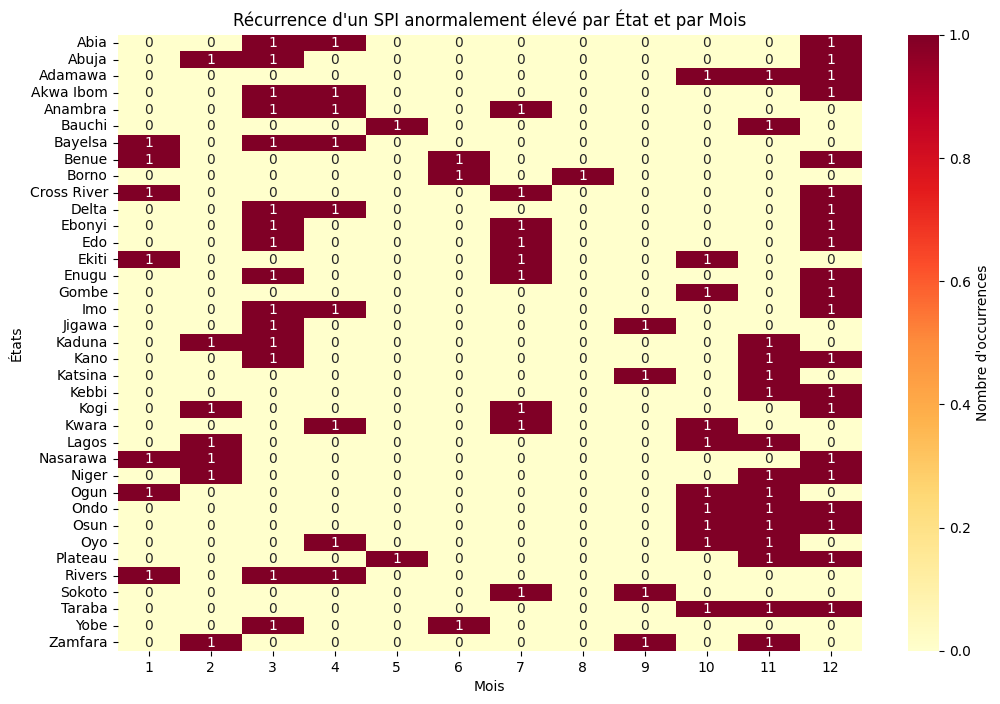

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

## HEATMAP SPI 

# 1. On pivote les données pour créer la matrice (États en lignes, Mois en colonnes)
# Assurez-vous que 'spi_hi_count' est bien le nom de votre colonne de compteur
pivot_df_SPI = SPI_summary.pivot(index="NAME_1", columns="month", values="spi_hi_count")

# 2. Création du heatmap avec la correction du label de légende
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df_SPI, 
            annot=True, 
            cmap="YlOrRd", 
            cbar_kws={'label': "Nombre d'occurrences"})

plt.title("Récurrence d'un SPI anormalement élevé par État et par Mois")
plt.xlabel("Mois")
plt.ylabel("États")

plt.savefig("heatmap_lean_season.png") # Sauvegarde pour votre rapport
plt.show()

In [72]:
pivot_df_SPI.head(5)

month,1,2,3,4,5,6,7,8,9,10,11,12
NAME_1,,,,,,,,,,,,
Abia,0,0,1,1,0,0,0,0,0,0,0,1
Abuja,0,1,1,0,0,0,0,0,0,0,0,1
Adamawa,0,0,0,0,0,0,0,0,0,1,1,1
Akwa Ibom,0,0,1,1,0,0,0,0,0,0,0,1
Anambra,0,0,1,1,0,0,1,0,0,0,0,0


In [73]:
pivot_df_SPI.sum()

month
1      7
2      7
3     15
4      9
5      2
6      3
7      9
8      1
9      4
10    10
11    15
12    21
dtype: int64

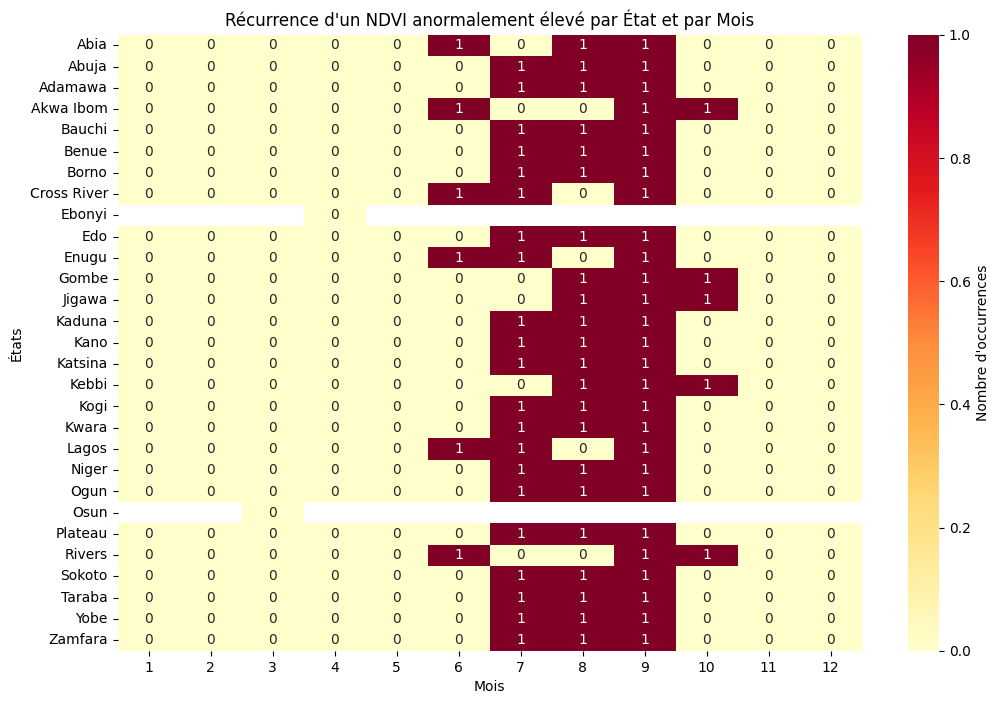

In [74]:

## HEATMAP NDVI 

# 1. On pivote les données pour créer la matrice (États en lignes, Mois en colonnes)
# Assurez-vous que 'spi_hi_count' est bien le nom de votre colonne de compteur
pivot_df_ndvi = ndvi_summary.pivot(index="NAME_1", columns="month", values="ndvi_hi_count")

# 2. Création du heatmap avec la correction du label de légende
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df_ndvi, 
            annot=True, 
            cmap="YlOrRd", 
            cbar_kws={'label': "Nombre d'occurrences"})

plt.title("Récurrence d'un NDVI anormalement élevé par État et par Mois")
plt.xlabel("Mois")
plt.ylabel("États")

plt.savefig("heatmap_ndvi.png") # Sauvegarde pour votre rapport
plt.show()

L'indicateur qui consiste a utiliser l'intersection de NDVI et SPI haut ne convient pas car il implique que seul le mois de juillet ferait partie de la lean season. Les deux heatmaps précedentes nous permettent de supposer que la période de risque maximale est atteinte en Juillet car les deux conditions : Stocks alimentaires écoulées et précipitations sont cumulées.

La limite de cet indicateur est qu'il ne permet pas de définir une période de soudure mais une période où les cultures sont accessibles mais où la pluie empêche les récoltes et sature les sols 

## Méthode 3 : Intersection entre la croissance de la végetation et pluies hautes


In [75]:
# Création du data frame pour NDVI, par an 
ndvi_yearly = (
    df.groupby(["NAME_1", "month","year"], as_index=False)
      .agg(ndvi=("vim", "mean"),
           n_obs=("vim", "size"),
           inadequate=("inadequate","mean"))
      .sort_values(["NAME_1","year"])
)

ndvi_yearly["ndvi_mean_admin"] = ndvi_yearly.groupby("NAME_1")["ndvi"].transform("mean")
ndvi_yearly["ndvi_std_admin"] = ndvi_yearly.groupby("NAME_1")["ndvi"].transform("std")
ndvi_yearly["ndvi_anom"] = (ndvi_yearly["ndvi"] - ndvi_yearly["ndvi_mean_admin"])/ ndvi_yearly["ndvi_std_admin"]
ndvi_yearly.head(45)


,NAME_1,month,year,ndvi,n_obs,inadequate,ndvi_mean_admin,ndvi_std_admin,ndvi_anom
0,Abia,1,2023,0.569790,1,0.296774,0.728118,0.087077,-1.818256
3,Abia,2,2023,0.598635,1,0.401515,0.728118,0.087077,-1.487003
6,Abia,3,2023,0.683211,1,0.281046,0.728118,0.087077,-0.515724
8,Abia,4,2023,0.751135,1,0.300613,0.728118,0.087077,0.264323
11,Abia,5,2023,0.790905,1,0.226667,0.728118,0.087077,0.721051
14,Abia,6,2023,0.806755,1,0.263514,0.728118,0.087077,0.903077
17,Abia,7,2023,0.803009,1,0.412903,0.728118,0.087077,0.860052
20,Abia,8,2023,0.805281,1,0.335443,0.728118,0.087077,0.886139
23,Abia,9,2023,0.814036,1,0.349315,0.728118,0.087077,0.986689
26,Abia,10,2023,0.802394,1,0.402597,0.728118,0.087077,0.852991


In [76]:
# Création du data frame pour SPI, par an
spi_yearly = (
    spi_df.groupby(["NAME_1", "month","year"], as_index=False)
      .agg(spi=("SPI_Cum1", "mean"),
           n_obs=("SPI_Cum1", "size"))
      .sort_values(["NAME_1","year"])
)

spi_yearly["spi_mean_admin"] = spi_yearly.groupby("NAME_1")["spi"].transform("mean")
spi_yearly["spi_std_admin"] = spi_yearly.groupby("NAME_1")["spi"].transform("std")
spi_yearly["spi_anom"] = (spi_yearly["spi"] - spi_yearly["spi_mean_admin"])/ spi_yearly["spi_std_admin"]
spi_yearly.head(45)


,NAME_1,month,year,spi,n_obs,spi_mean_admin,spi_std_admin,spi_anom
0,Abia,1,2023,-0.69100,1,-0.649667,1.083001,-0.038166
3,Abia,2,2023,-1.83400,1,-0.649667,1.083001,-1.093566
6,Abia,3,2023,0.74900,1,-0.649667,1.083001,1.291473
9,Abia,4,2023,-0.05100,1,-0.649667,1.083001,0.552785
12,Abia,5,2023,-0.29500,1,-0.649667,1.083001,0.327485
15,Abia,6,2023,1.36500,1,-0.649667,1.083001,1.860262
18,Abia,7,2023,-0.46200,1,-0.649667,1.083001,0.173284
21,Abia,8,2023,-1.83400,1,-0.649667,1.083001,-1.093566
24,Abia,9,2023,-0.06600,1,-0.649667,1.083001,0.538934
27,Abia,10,2023,-0.28900,1,-0.649667,1.083001,0.333025


In [77]:
summary_lean_season_yearly = ndvi_yearly.merge(spi_yearly, on=['NAME_1', 'month','year'])
summary_lean_season_yearly.head(5)

,NAME_1,month,year,ndvi,n_obs_x,inadequate,ndvi_mean_admin,ndvi_std_admin,ndvi_anom,spi,n_obs_y,spi_mean_admin,spi_std_admin,spi_anom
0,Abia,1,2023,0.569790,1,0.296774,0.728118,0.087077,-1.818256,-0.691,1,-0.649667,1.083001,-0.038166
1,Abia,2,2023,0.598635,1,0.401515,0.728118,0.087077,-1.487003,-1.834,1,-0.649667,1.083001,-1.093566
2,Abia,3,2023,0.683211,1,0.281046,0.728118,0.087077,-0.515724,0.749,1,-0.649667,1.083001,1.291473
3,Abia,4,2023,0.751135,1,0.300613,0.728118,0.087077,0.264323,-0.051,1,-0.649667,1.083001,0.552785
4,Abia,5,2023,0.790905,1,0.226667,0.728118,0.087077,0.721051,-0.295,1,-0.649667,1.083001,0.327485


In [78]:
summary_lean_season_yearly.drop(columns = ["n_obs_x", "n_obs_y"])


,NAME_1,month,year,ndvi,inadequate,ndvi_mean_admin,ndvi_std_admin,ndvi_anom,spi,spi_mean_admin,spi_std_admin,spi_anom
0,Abia,1,2023,0.569790,0.296774,0.728118,0.087077,-1.818256,-0.6910,-0.649667,1.083001,-0.038166
1,Abia,2,2023,0.598635,0.401515,0.728118,0.087077,-1.487003,-1.8340,-0.649667,1.083001,-1.093566
2,Abia,3,2023,0.683211,0.281046,0.728118,0.087077,-0.515724,0.7490,-0.649667,1.083001,1.291473
3,Abia,4,2023,0.751135,0.300613,0.728118,0.087077,0.264323,-0.0510,-0.649667,1.083001,0.552785
4,Abia,5,2023,0.790905,0.226667,0.728118,0.087077,0.721051,-0.2950,-0.649667,1.083001,0.327485
...,...,...,...,...,...,...,...,...,...,...,...,...
942,Zamfara,8,2025,0.670072,0.500000,0.421726,0.159200,1.559966,-0.2210,0.559265,1.129352,-0.690896
943,Zamfara,9,2025,0.674001,0.453333,0.421726,0.159200,1.584648,1.0005,0.559265,1.129352,0.390698
944,Zamfara,10,2025,0.584691,0.427673,0.421726,0.159200,1.023653,1.1085,0.559265,1.129352,0.486328
945,Zamfara,11,2025,0.445775,0.415301,0.421726,0.159200,0.151063,3.3270,0.559265,1.129352,2.450729


On va définir la lean season comme un moment où la végetation est en croissance et le SPI est bas, lorsque la végetation atteint son maximum, on considère que la lean season prend fin 

In [79]:
# Calcul du taux de croissance de la végetation 

summary_lean_season_yearly["ndvi_growth_mom"] = summary_lean_season_yearly.groupby(["NAME_1"])["ndvi"].pct_change() #Fonction qui compare avec la ligne d'au dessus au sein d'un meme groupe
summary_lean_season_yearly.head(12)

,NAME_1,month,year,ndvi,n_obs_x,inadequate,ndvi_mean_admin,ndvi_std_admin,ndvi_anom,spi,n_obs_y,spi_mean_admin,spi_std_admin,spi_anom,ndvi_growth_mom
0,Abia,1,2023,0.569790,1,0.296774,0.728118,0.087077,-1.818256,-0.691,1,-0.649667,1.083001,-0.038166,NaN
1,Abia,2,2023,0.598635,1,0.401515,0.728118,0.087077,-1.487003,-1.834,1,-0.649667,1.083001,-1.093566,0.050623
2,Abia,3,2023,0.683211,1,0.281046,0.728118,0.087077,-0.515724,0.749,1,-0.649667,1.083001,1.291473,0.141281
3,Abia,4,2023,0.751135,1,0.300613,0.728118,0.087077,0.264323,-0.051,1,-0.649667,1.083001,0.552785,0.099419
4,Abia,5,2023,0.790905,1,0.226667,0.728118,0.087077,0.721051,-0.295,1,-0.649667,1.083001,0.327485,0.052947
5,Abia,6,2023,0.806755,1,0.263514,0.728118,0.087077,0.903077,1.365,1,-0.649667,1.083001,1.860262,0.020041
6,Abia,7,2023,0.803009,1,0.412903,0.728118,0.087077,0.860052,-0.462,1,-0.649667,1.083001,0.173284,-0.004644
7,Abia,8,2023,0.805281,1,0.335443,0.728118,0.087077,0.886139,-1.834,1,-0.649667,1.083001,-1.093566,0.002829
8,Abia,9,2023,0.814036,1,0.349315,0.728118,0.087077,0.986689,-0.066,1,-0.649667,1.083001,0.538934,0.010873
9,Abia,10,2023,0.802394,1,0.402597,0.728118,0.087077,0.852991,-0.289,1,-0.649667,1.083001,0.333025,-0.014302


In [80]:
#Création d'un indicatrice de SPI haut et croissance de la végetation ==> indique une phase post semance 

#Création des variables : 
q = 0.70  # 20e percentile

## 1. SPI_haut
# seuil par Etat (répété sur chaque ligne de l'Etat)
summary_lean_season_yearly["spi_q70_threshold"] = (
    summary_lean_season_yearly.groupby(["NAME_1","year"])["spi_anom"]
    .transform(lambda s: s.quantile(q))
)

# indicateur SPI haut
summary_lean_season_yearly["spi_hi_q70"] = summary_lean_season_yearly["spi_anom"] > summary_lean_season_yearly["spi_q70_threshold"]

## 2. NDVI max = fin de la lean season 
summary_lean_season_yearly["ndvi_max"] = summary_lean_season_yearly.groupby(["NAME_1","year"])["ndvi"].transform("max")

## 3. NDVI en croissance :

summary_lean_season_yearly["ndvi_is_growing"] = summary_lean_season_yearly["ndvi_growth_mom"] > 0

## 4. Indicatrice Lean Season :
summary_lean_season_yearly["lean_season"] = (
    (summary_lean_season_yearly["spi_anom"] > 0) & 
    (summary_lean_season_yearly["ndvi_is_growing"] == True) & 
    (summary_lean_season_yearly["ndvi"] < summary_lean_season_yearly["ndvi_max"])
)
summary_lean_season_yearly.head()



,NAME_1,month,year,ndvi,n_obs_x,inadequate,ndvi_mean_admin,ndvi_std_admin,ndvi_anom,spi,n_obs_y,spi_mean_admin,spi_std_admin,spi_anom,ndvi_growth_mom,spi_q70_threshold,spi_hi_q70,ndvi_max,ndvi_is_growing,lean_season
0,Abia,1,2023,0.569790,1,0.296774,0.728118,0.087077,-1.818256,-0.691,1,-0.649667,1.083001,-0.038166,NaN,0.487411,False,0.814036,False,False
1,Abia,2,2023,0.598635,1,0.401515,0.728118,0.087077,-1.487003,-1.834,1,-0.649667,1.083001,-1.093566,0.050623,0.487411,False,0.814036,True,False
2,Abia,3,2023,0.683211,1,0.281046,0.728118,0.087077,-0.515724,0.749,1,-0.649667,1.083001,1.291473,0.141281,0.487411,True,0.814036,True,True
3,Abia,4,2023,0.751135,1,0.300613,0.728118,0.087077,0.264323,-0.051,1,-0.649667,1.083001,0.552785,0.099419,0.487411,True,0.814036,True,True
4,Abia,5,2023,0.790905,1,0.226667,0.728118,0.087077,0.721051,-0.295,1,-0.649667,1.083001,0.327485,0.052947,0.487411,False,0.814036,True,True


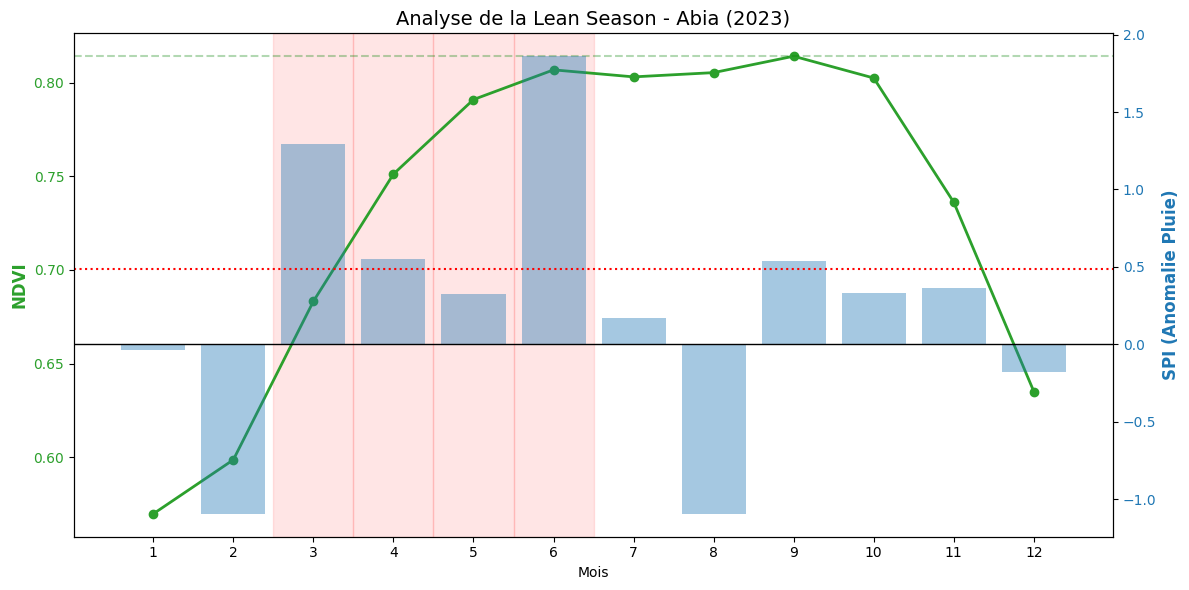

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# On filtre les données pour l'État d'Abia et l'année 2023
data_abia = summary_lean_season_yearly[(summary_lean_season_yearly['NAME_1'] == 'Abia') & 
                                      (summary_lean_season_yearly['year'] == 2023)].sort_values('month')

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Axe 1 : NDVI (Végétation) ---
color_ndvi = 'tab:green'
ax1.set_xlabel('Mois')
ax1.set_ylabel('NDVI', color=color_ndvi, fontsize=12, fontweight='bold')
ax1.plot(data_abia['month'], data_abia['ndvi'], color=color_ndvi, marker='o', linewidth=2, label='NDVI')
ax1.tick_params(axis='y', labelcolor=color_ndvi)

# Ajout du NDVI Max pour référence
ax1.axhline(data_abia['ndvi_max'].iloc[0], color='green', linestyle='--', alpha=0.3, label='NDVI Max Annual')

# --- Axe 2 : SPI (Précipitations) ---
ax2 = ax1.twinx()
color_spi = 'tab:blue'
ax2.set_ylabel('SPI (Anomalie Pluie)', color=color_spi, fontsize=12, fontweight='bold')
ax2.bar(data_abia['month'], data_abia['spi_anom'], color=color_spi, alpha=0.4, label='SPI Anom')
ax2.axhline(0, color='black', linewidth=1) # Ligne de base
ax2.axhline(data_abia['spi_q70_threshold'].iloc[0], color='red', linestyle=':', label='Seuil Q70')
ax2.tick_params(axis='y', labelcolor=color_spi)

# --- Mise en évidence de la Lean Season ---
# On colorie le fond là où lean_season == True
for i in range(len(data_abia)):
    if data_abia['lean_season'].iloc[i]:
        ax1.axvspan(data_abia['month'].iloc[i]-0.5, data_abia['month'].iloc[i]+0.5, 
                    color='red', alpha=0.1, label='Lean Season' if i == 2 else "")

plt.title('Analyse de la Lean Season - Abia (2023)', fontsize=14)
plt.xticks(range(1, 13))
fig.tight_layout()
plt.show()

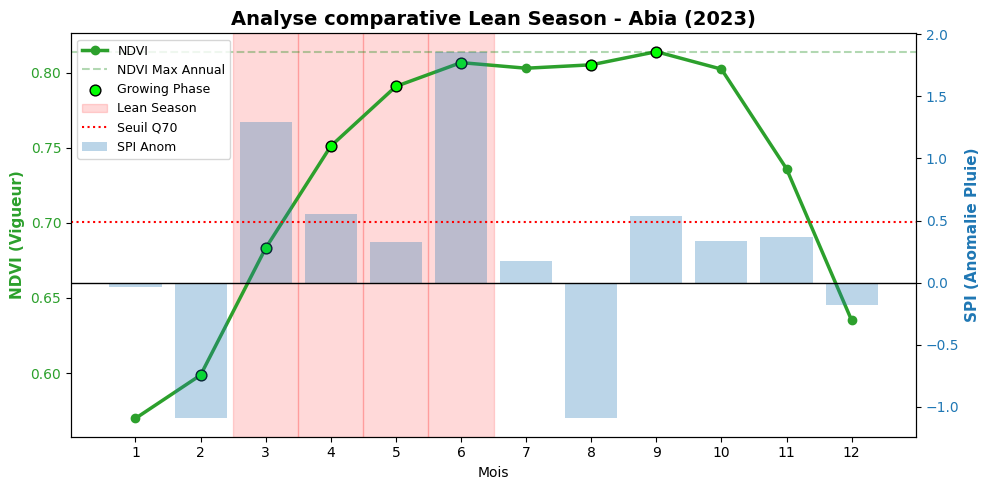

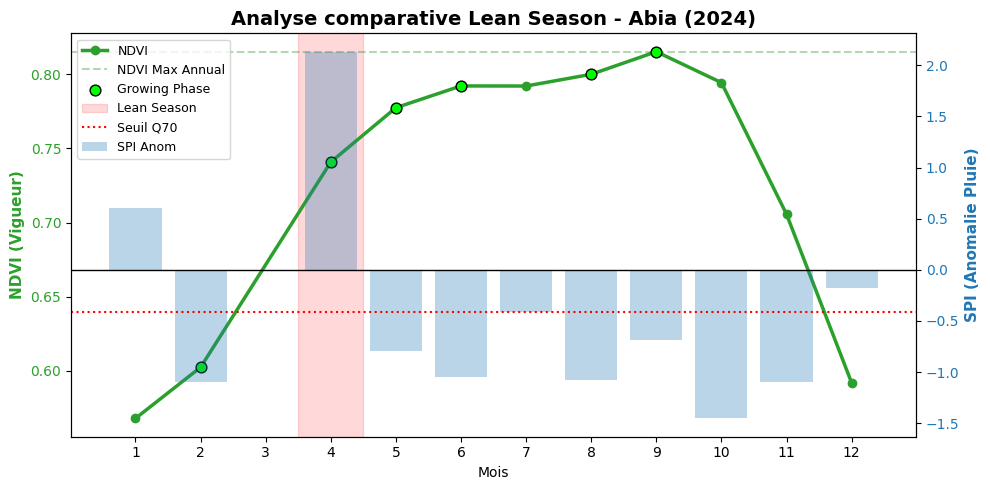

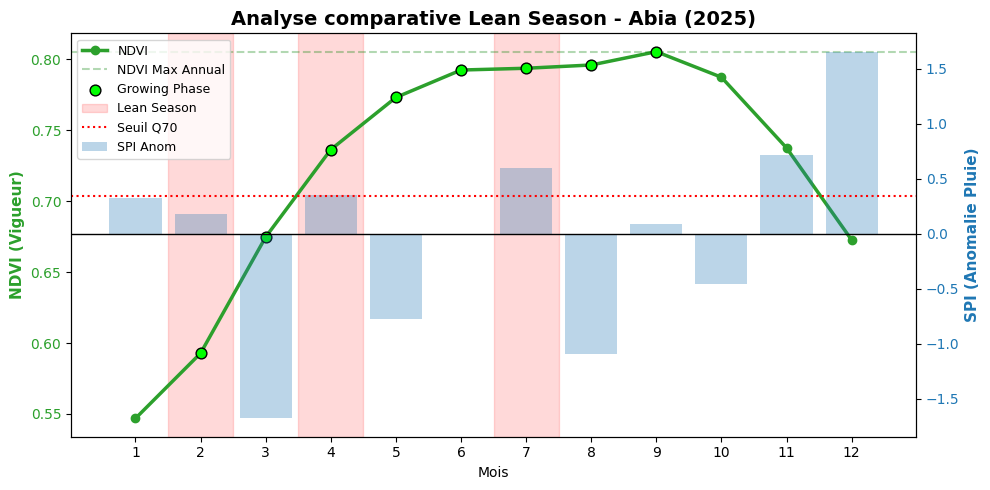

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Filtrer les données pour Abia et s'assurer du tri chronologique
# (Vérifie bien que ton DataFrame s'appelle summary_lean_season_yearly)
df_abia = summary_lean_season_yearly[summary_lean_season_yearly['NAME_1'] == 'Abia'].sort_values(['year', 'month'])

# 2. Boucle pour générer un graphique par année
for year in [2023, 2024, 2025]:
    
    # Filtrer par année
    data_year = df_abia[df_abia['year'] == year]
    
    # Vérification si données existantes pour l'année
    if data_year.empty:
        print(f"Pas de données pour l'année {year}")
        continue

    # Initialisation de la figure
    fig, ax1 = plt.subplots(figsize=(10, 5))
    plt.title(f'Analyse comparative Lean Season - Abia ({year})', fontsize=14, fontweight='bold')

    # --- Axe 1 : NDVI (Végétation) ---
    color_ndvi = 'tab:green'
    ax1.set_xlabel('Mois')
    ax1.set_ylabel('NDVI (Vigueur)', color=color_ndvi, fontsize=11, fontweight='bold')
    
    # Courbe NDVI actuel
    ax1.plot(data_year['month'], data_year['ndvi'], color=color_ndvi, marker='o', linewidth=2.5, label='NDVI')
    
    # Ligne de référence NDVI Max Annuel
    if 'ndvi_max' in data_year.columns:
        ax1.axhline(data_year['ndvi_max'].iloc[0], color='green', linestyle='--', alpha=0.3, label='NDVI Max Annual')
    
    # Condition Phénologique : is_growing (Mise en évidence sur la courbe)
    growing_months = data_year[data_year['ndvi_is_growing'] == True]
    ax1.scatter(growing_months['month'], growing_months['ndvi'], color='lime', edgecolors='black', s=60, zorder=3, label='Growing Phase')
    
    ax1.tick_params(axis='y', labelcolor=color_ndvi)
    ax1.set_xticks(range(1, 13))

    # --- Axe 2 : SPI (Précipitations) ---
    ax2 = ax1.twinx()
    color_spi = 'tab:blue'
    ax2.set_ylabel('SPI (Anomalie Pluie)', color=color_spi, fontsize=11, fontweight='bold')
    
    # Barres pour l'anomalie SPI
    ax2.bar(data_year['month'], data_year['spi_anom'], color=color_spi, alpha=0.3, label='SPI Anom')
    
    # Ligne de base 0
    ax2.axhline(0, color='black', linewidth=1)
    
    # Seuil critique SPI_hi_q70
    if 'spi_q70_threshold' in data_year.columns:
        ax2.axhline(data_year['spi_q70_threshold'].iloc[0], color='red', linestyle=':', label='Seuil Q70')
    
    ax2.tick_params(axis='y', labelcolor=color_spi)

    # --- Surlignage de la zone Lean Season ---
    # On ajoute un fond rouge transparent là où lean_season == True
    first_legend = True
    for i in range(len(data_year)):
        if data_year['lean_season'].iloc[i]:
            label_ls = 'Lean Season' if first_legend else ""
            ax1.axvspan(data_year['month'].iloc[i]-0.5, data_year['month'].iloc[i]+0.5, 
                        color='red', alpha=0.15, label=label_ls)
            first_legend = False

    # Gestion des légendes (on regroupe celles des deux axes)
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    # On supprime les doublons de légendes potentielles (growing phase)
    # unique_labels = dict(zip(labels_1 + labels_2, lines_1 + lines_2))
    # ax1.legend(unique_labels.values(), unique_labels.keys(), loc='upper left', fontsize=9)
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=9, frameon=True)

    fig.tight_layout()
    plt.show() # Affiche le graphique pour l'année en cours
    # plt.savefig(f"abia_lean_season_{year}.png") # Optionnel : sauvegarder l'image

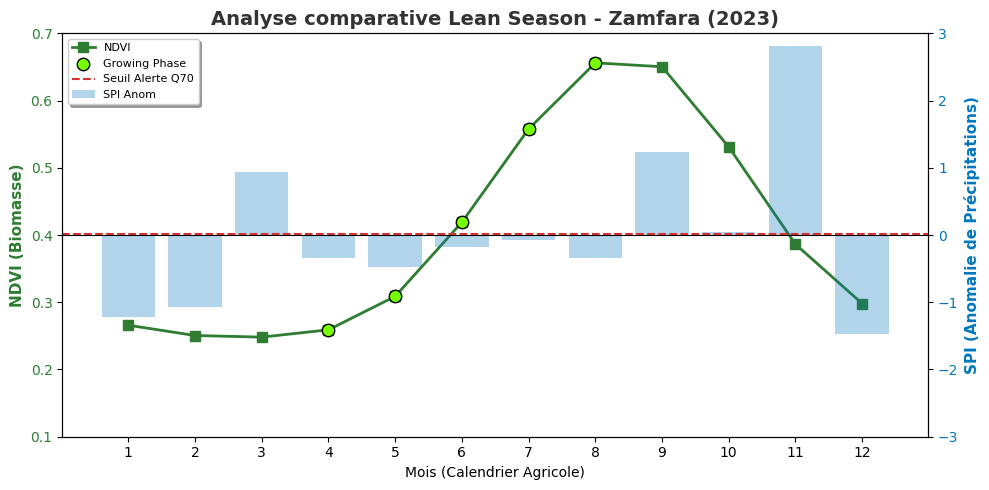

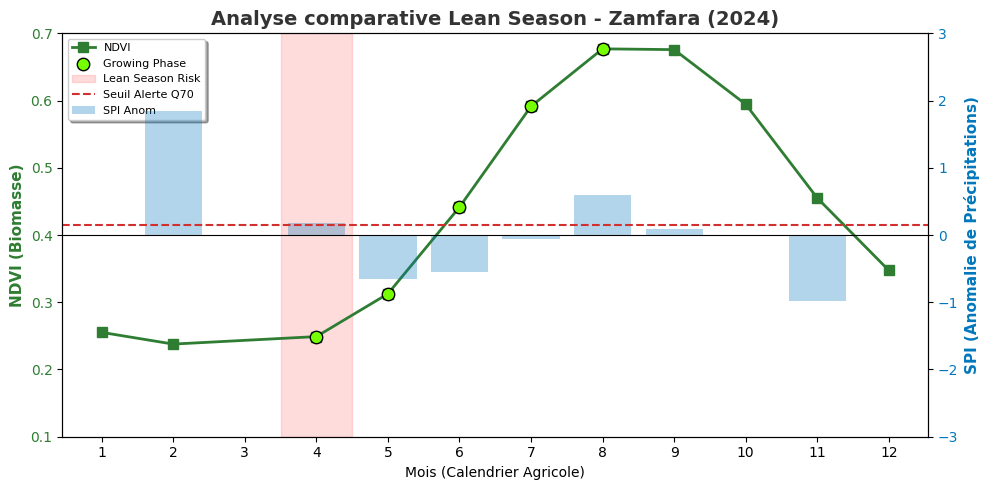

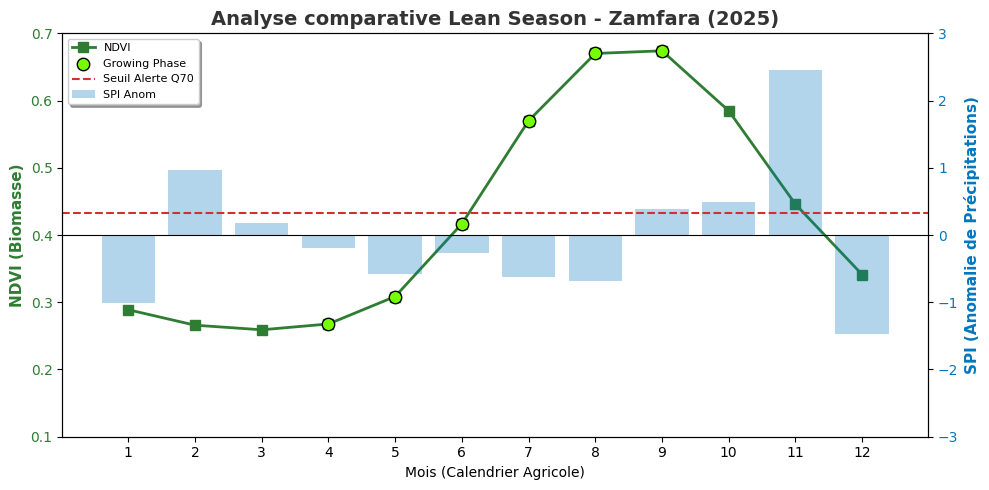

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtrer les données pour Zamfara
df_zamfara = summary_lean_season_yearly[summary_lean_season_yearly['NAME_1'] == 'Zamfara'].sort_values(['year', 'month'])

# 2. Boucle pour générer les graphiques annuels
for year in [2023, 2024, 2025]:
    
    data_year = df_zamfara[df_zamfara['year'] == year]
    
    if data_year.empty:
        continue

    fig, ax1 = plt.subplots(figsize=(10, 5))
    plt.title(f'Analyse comparative Lean Season - Zamfara ({year})', fontsize=14, fontweight='bold', color='#333333')

    # --- Axe 1 : NDVI (Végétation du Sahel/Soudan) ---
    color_ndvi = '#2E7D32' # Vert plus foncé pour le contraste
    ax1.set_xlabel('Mois (Calendrier Agricole)')
    ax1.set_ylabel('NDVI (Biomasse)', color=color_ndvi, fontsize=11, fontweight='bold')
    
    # Courbe NDVI
    ax1.plot(data_year['month'], data_year['ndvi'], color=color_ndvi, marker='s', markersize=7, linewidth=2, label='NDVI')
    
    # Phase de croissance (Growing Phase)
    growing = data_year[data_year['ndvi_is_growing'] == True]
    ax1.scatter(growing['month'], growing['ndvi'], color='#76FF03', edgecolors='black', s=80, zorder=3, label='Growing Phase')
    
    # Limites d'axe pour Zamfara (souvent entre 0.2 et 0.6)
    ax1.set_ylim(0.1, 0.7)
    ax1.tick_params(axis='y', labelcolor=color_ndvi)
    ax1.set_xticks(range(1, 13))

    # --- Axe 2 : SPI (Pluies Sahéliennes) ---
    ax2 = ax1.twinx()
    color_spi = '#0277BD'
    ax2.set_ylabel('SPI (Anomalie de Précipitations)', color=color_spi, fontsize=11, fontweight='bold')
    
    # Barres SPI
    ax2.bar(data_year['month'], data_year['spi_anom'], color=color_spi, alpha=0.3, label='SPI Anom')
    ax2.axhline(0, color='black', linewidth=0.8)
    
    # Seuil Q70 (Risque d'inondation/excès)
    if 'spi_q70_threshold' in data_year.columns:
        ax2.axhline(data_year['spi_q70_threshold'].iloc[0], color='#D32F2F', linestyle='--', linewidth=1.5, label='Seuil Alerte Q70')
    
    ax2.set_ylim(-3, 3) # Fixer l'échelle SPI pour comparer les années
    ax2.tick_params(axis='y', labelcolor=color_spi)

    # --- Zone de Lean Season (Soudure) ---
    ls_handle = None
    for i in range(len(data_year)):
        if data_year['lean_season'].iloc[i]:
            ls_handle = ax1.axvspan(data_year['month'].iloc[i]-0.5, data_year['month'].iloc[i]+0.5, 
                                    color='#FF5252', alpha=0.2, label='Lean Season Risk')

    # Regrouper les légendes proprement
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    # On évite de répéter "Lean Season Risk" dans la légende
    unique = dict(zip(l1 + l2, h1 + h2))
    ax1.legend(unique.values(), unique.keys(), loc='upper left', fontsize=8, frameon=True, shadow=True)

    plt.grid(axis='x', alpha=0.2)
    plt.tight_layout()
    plt.show()

On ne remarque pas l'existence de périodes de soudure définies donc on étudie l'impact de SPI sur la croissance de la végetation

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agréger les données au niveau annuel par État
# On prend la moyenne de l'anomalie SPI et la moyenne de la croissance NDVI
annual_stats = summary_lean_season_yearly.groupby(['NAME_1', 'year']).agg({
    'spi_anom': 'mean',
    'ndvi_growth_mom': 'mean'
}).reset_index()

# 2. Créer la variable "Croissance de l'année suivante"
# On décale la colonne ndvi_growth vers le haut (-1) au sein de chaque État
annual_stats['next_year_growth'] = annual_stats.groupby('NAME_1')["ndvi_growth_mom"].shift(-1)

# 3. Supprimer les lignes vides (l'année 2025 n'a pas de 2026 pour comparer)
df_corr = annual_stats.dropna(subset=['next_year_growth'])

# 4. Calculer la corrélation par État
# Note : avec 2 points, on observe surtout si les deux variables évoluent dans le même sens
state_correlations = df_corr.groupby('NAME_1').apply(
    lambda x: x['spi_anom'].corr(x['next_year_growth'])
).reset_index()
state_correlations.columns = ['NAME_1', 'correlation']

/tmp/ipykernel_151659/283781176.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  state_correlations = df_corr.groupby('NAME_1').apply(


/tmp/ipykernel_151659/551174141.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_correlations, y='NAME_1', x='correlation', palette='coolwarm')


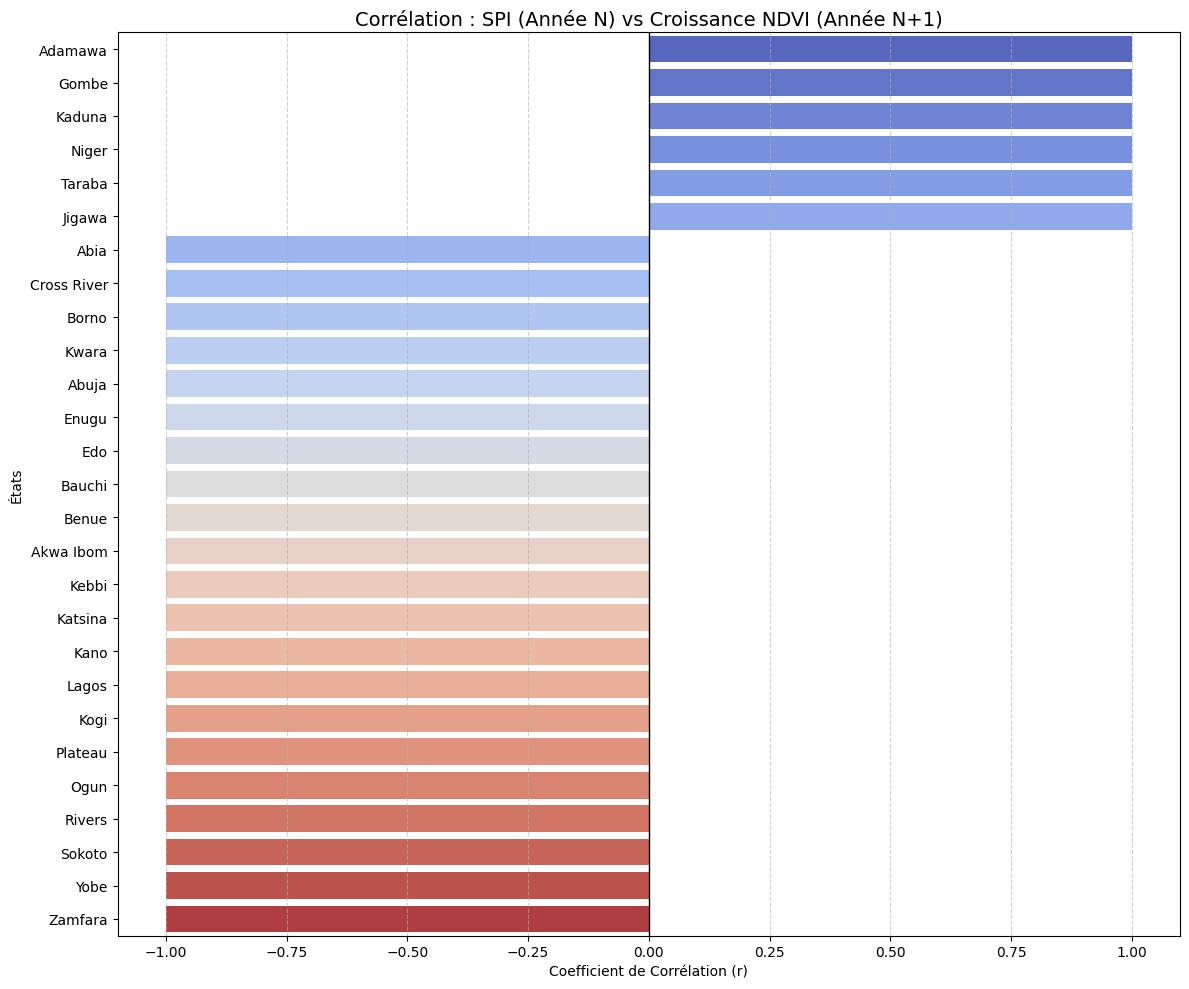

In [85]:
# Trier les résultats
state_correlations = state_correlations.sort_values('correlation', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(data=state_correlations, y='NAME_1', x='correlation', palette='coolwarm')

plt.axvline(0, color='black', linewidth=1)
plt.title('Corrélation : SPI (Année N) vs Croissance NDVI (Année N+1)', fontsize=14)
plt.xlabel('Coefficient de Corrélation (r)')
plt.ylabel('États')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

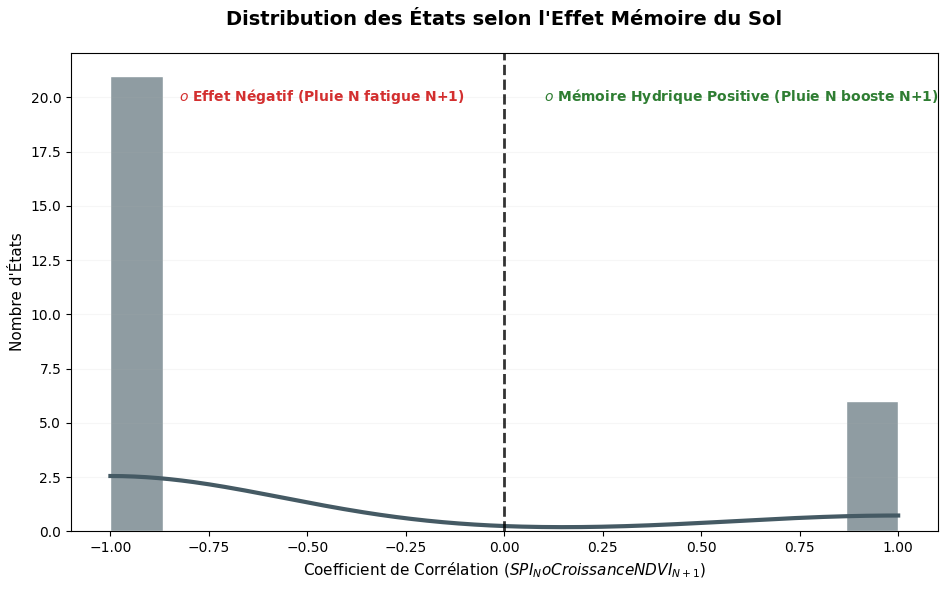

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Nettoyage des données (suppression des valeurs manquantes éventuelles)
# Vérifie que ta colonne s'appelle bien 'correlation'
df_plot = state_correlations.dropna(subset=['correlation'])

# 2. Création de l'Histogramme + Courbe de Densité (Synthèse Globale)
plt.figure(figsize=(10, 6))

# Palette de couleurs sobre et professionnelle
color_main = '#455A64' # Bleu-Gris foncé

# displot est la fonction moderne de seaborn pour les distributions
sns.histplot(data=df_plot, 
             x='correlation', 
             kde=True,          # Ajoute la courbe de densité lisse
             bins=15,           # Nombre de barres pour l'histogramme
             color=color_main, 
             edgecolor='white', # Sépare bien les barres
             linewidth=1,
             line_kws={'linewidth': 3}, # Épaisseur de la courbe KDE
             alpha=0.6)         # Transparence des barres

# 3. Éléments de lecture scientifiques et clairs
# Ligne de référence à 0 (Pas de corrélation / Pas d'effet mémoire)
plt.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.8)

# Titre et labels explicites pour ton rapport
plt.title('Distribution des États selon l\'Effet Mémoire du Sol', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Coefficient de Corrélation ($SPI_{N} \to CroissanceNDVI_{N+1}$)', fontsize=11)
plt.ylabel('Nombre d\'États', fontsize=11)

# Ajout de texte explicatif directement sur le graphique
plt.text(0.1, plt.gca().get_ylim()[1]*0.9, '$\to$ Mémoire Hydrique Positive (Pluie N booste N+1)', 
         fontsize=10, color='#2E7D32', fontweight='bold')
plt.text(-0.1, plt.gca().get_ylim()[1]*0.9, '$\to$ Effet Négatif (Pluie N fatigue N+1)', 
         fontsize=10, color='#D32F2F', fontweight='bold', ha='right')

plt.grid(axis='y', linestyle='-', alpha=0.1)
plt.tight_layout()
plt.show()

On remarque une corrélation surtout négative entre l'indicateur SPI et la croissance de la végetation, on peut donc également considérer la variable Soil Moisture 10 cm 

In [87]:
df.columns

Index(['time', 'NAME_1', 'inadequate', 'bnds', 'Y', 'X', 'Evap_tavg',
       'LWdown_f_tavg', 'Lwnet_tavg', 'Psurf_f_tavg', 'Qair_f_tavg', 'Qg_tavg',
       'Qh_tavg', 'Qle_tavg', 'Qs_tavg', 'RadT_tavg', 'Rainf_f_tavg',
       'SWdown_f_tavg', 'Swnet_tavg', 'Tair_f_tavg', 'Wind_f_tavg',
       'SoilMoi00_10cm_tavg', 'SoilMoi10_40cm_tavg', 'SoilMoi40_100cm_tavg',
       'SoilMoi100_200cm_tavg', 'SoilTemp00_10cm_tavg', 'SoilTemp10_40cm_tavg',
       'SoilTemp40_100cm_tavg', 'SoilTemp100_200cm_tavg', 'vim', 'viq', 'year',
       'ndvi', 'month'],
      dtype='object')

In [88]:
# On sélectionne les colonnes de fusion ET la donnée cible
soil_temp_data = df[["NAME_1", "year", "month", "SoilMoi00_10cm_tavg","SoilTemp00_10cm_tavg","Tair_f_tavg"]]

# On fusionne proprement
summary_lean_season_yearly = summary_lean_season_yearly.merge(
    soil_temp_data, 
    on=["NAME_1", "year", "month"], 
    how="left"
)
summary_lean_season_yearly.head(10)

,NAME_1,month,year,ndvi,n_obs_x,inadequate,ndvi_mean_admin,ndvi_std_admin,ndvi_anom,spi,...,spi_anom,ndvi_growth_mom,spi_q70_threshold,spi_hi_q70,ndvi_max,ndvi_is_growing,lean_season,SoilMoi00_10cm_tavg,SoilTemp00_10cm_tavg,Tair_f_tavg
0,Abia,1,2023,0.569790,1,0.296774,0.728118,0.087077,-1.818256,-0.691,...,-0.038166,NaN,0.487411,False,0.814036,False,False,0.280146,300.138219,299.067207
1,Abia,2,2023,0.598635,1,0.401515,0.728118,0.087077,-1.487003,-1.834,...,-1.093566,0.050623,0.487411,False,0.814036,True,False,0.285749,301.087698,299.804101
2,Abia,3,2023,0.683211,1,0.281046,0.728118,0.087077,-0.515724,0.749,...,1.291473,0.141281,0.487411,True,0.814036,True,True,0.379098,299.624543,299.479913
3,Abia,4,2023,0.751135,1,0.300613,0.728118,0.087077,0.264323,-0.051,...,0.552785,0.099419,0.487411,True,0.814036,True,True,0.391225,299.950588,299.790130
4,Abia,5,2023,0.790905,1,0.226667,0.728118,0.087077,0.721051,-0.295,...,0.327485,0.052947,0.487411,False,0.814036,True,True,0.410964,299.604193,299.846143
5,Abia,6,2023,0.806755,1,0.263514,0.728118,0.087077,0.903077,1.365,...,1.860262,0.020041,0.487411,True,0.814036,True,True,0.425842,298.469559,298.496977
6,Abia,7,2023,0.803009,1,0.412903,0.728118,0.087077,0.860052,-0.462,...,0.173284,-0.004644,0.487411,False,0.814036,False,False,0.428507,298.492839,298.585825
7,Abia,8,2023,0.805281,1,0.335443,0.728118,0.087077,0.886139,-1.834,...,-1.093566,0.002829,0.487411,False,0.814036,True,False,0.424155,298.498591,298.421593
8,Abia,9,2023,0.814036,1,0.349315,0.728118,0.087077,0.986689,-0.066,...,0.538934,0.010873,0.487411,True,0.814036,True,False,0.428628,298.552220,298.669431
9,Abia,10,2023,0.802394,1,0.402597,0.728118,0.087077,0.852991,-0.289,...,0.333025,-0.014302,0.487411,False,0.814036,False,False,0.427571,298.757006,299.058053


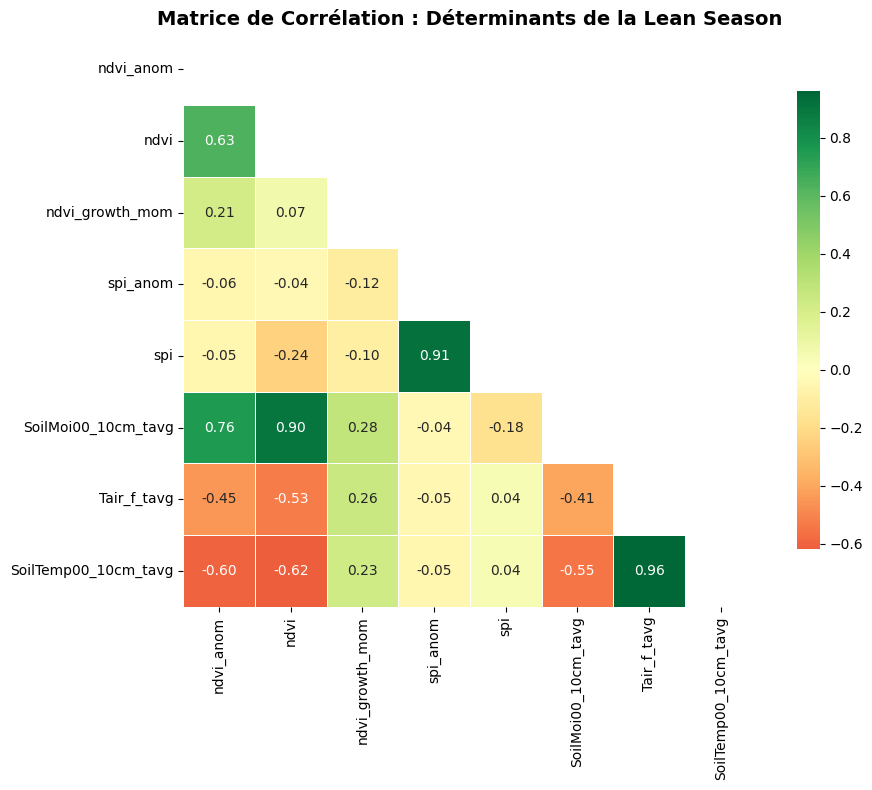

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sélection des variables clés
# On s'assure que SoilMoi00_10cm_tavg est bien présent dans summary_lean_season_yearly
cols_for_corr = ['ndvi_anom','ndvi', 'ndvi_growth_mom', 'spi_anom','spi', 'SoilMoi00_10cm_tavg','Tair_f_tavg','SoilTemp00_10cm_tavg']

# 2. Calcul de la matrice (Pearson par défaut)
# On utilise .dropna() pour ignorer les mois sans croissance (ex: Janvier)
corr_matrix = summary_lean_season_yearly[cols_for_corr].dropna().corr()

# 3. Création de la Heatmap
plt.figure(figsize=(10, 8))

# Masque pour ne voir que la partie inférieure (évite la répétition en miroir)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True,          # Affiche les valeurs de corrélation
            fmt=".2f",           # 2 décimales
            cmap='RdYlGn',       # Rouge (Négatif), Jaune (Neutre), Vert (Positif)
            center=0, 
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .8})

plt.title('Matrice de Corrélation : Déterminants de la Lean Season', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

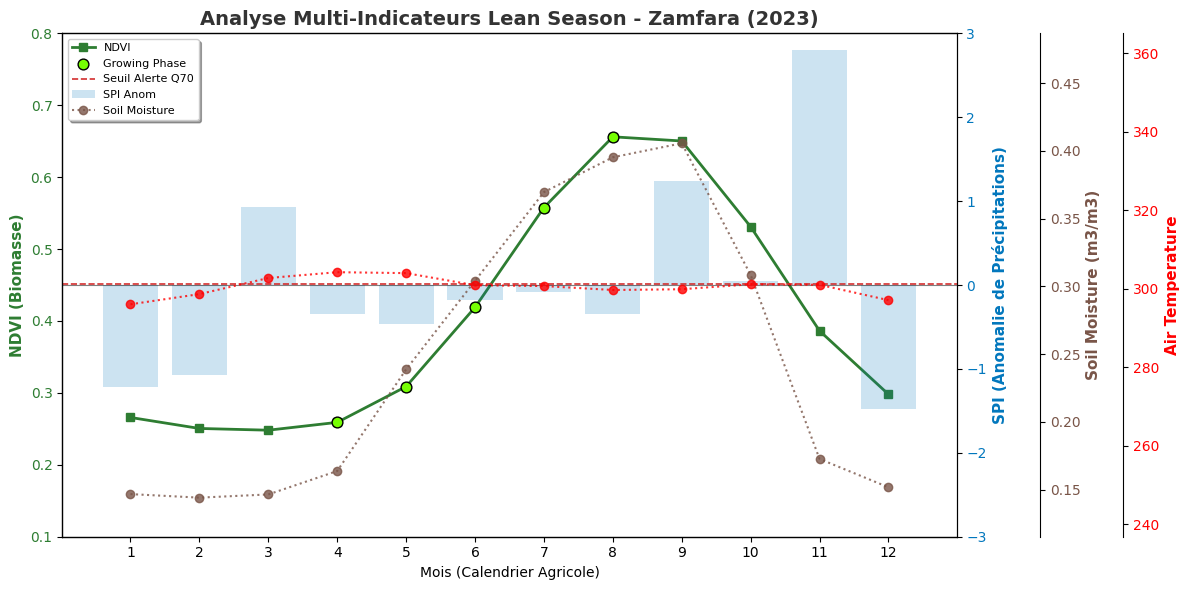

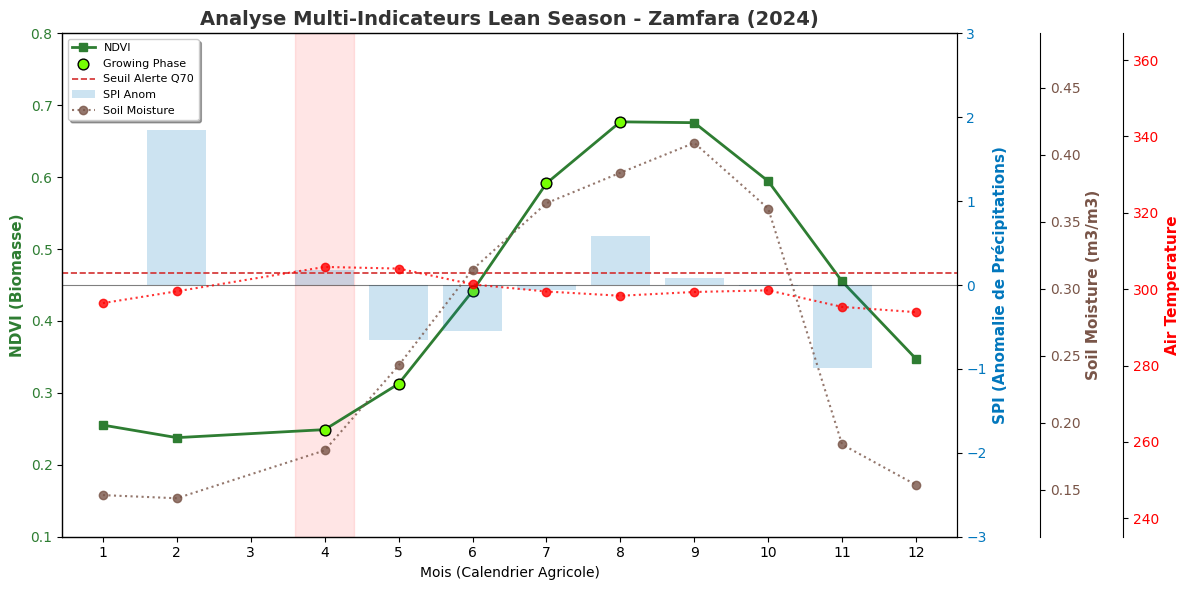

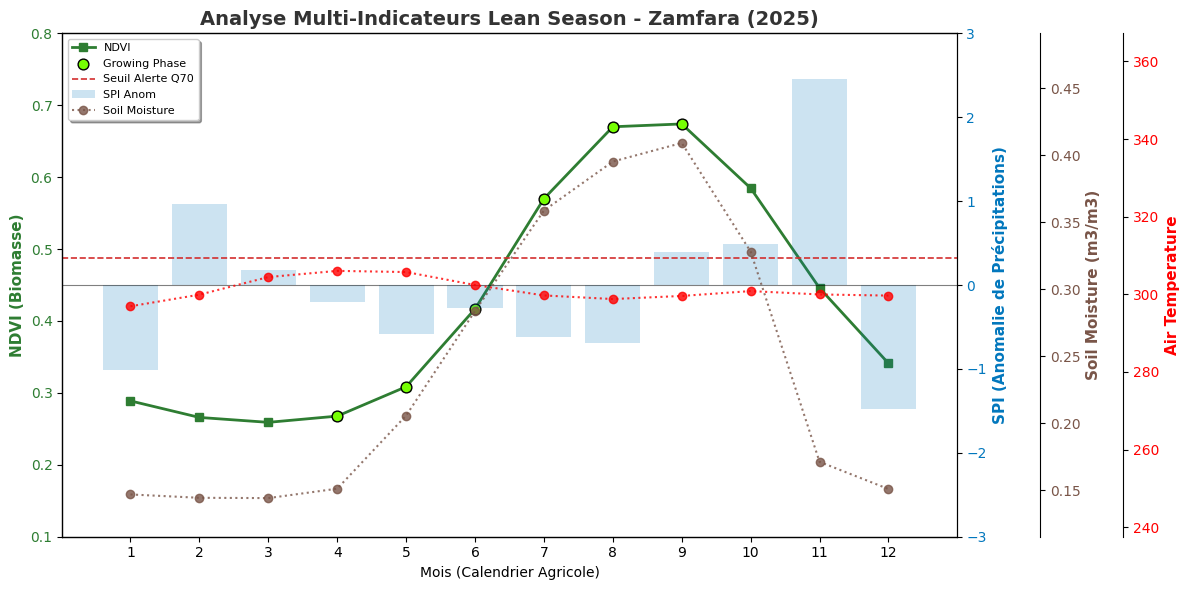

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtrer les données pour Zamfara
df_zamfara = summary_lean_season_yearly[summary_lean_season_yearly['NAME_1'] == 'Zamfara'].sort_values(['year', 'month'])

# 2. Boucle pour générer les graphiques annuels
for year in [2023, 2024, 2025]:
    
    data_year = df_zamfara[df_zamfara['year'] == year]
    
    if data_year.empty:
        continue

    fig, ax1 = plt.subplots(figsize=(12, 6))
    plt.title(f'Analyse Multi-Indicateurs Lean Season - Zamfara ({year})', fontsize=14, fontweight='bold', color='#333333')

    # --- Axe 1 : NDVI (Végétation) ---
    color_ndvi = '#2E7D32' 
    ax1.set_xlabel('Mois (Calendrier Agricole)')
    ax1.set_ylabel('NDVI (Biomasse)', color=color_ndvi, fontsize=11, fontweight='bold')
    
    ax1.plot(data_year['month'], data_year['ndvi'], color=color_ndvi, marker='s', markersize=6, linewidth=2, label='NDVI', zorder=5)
    
    # Phase de croissance
    growing = data_year[data_year['ndvi_is_growing'] == True]
    ax1.scatter(growing['month'], growing['ndvi'], color='#76FF03', edgecolors='black', s=60, zorder=6, label='Growing Phase')
    
    ax1.set_ylim(0.1, 0.8)
    ax1.tick_params(axis='y', labelcolor=color_ndvi)
    ax1.set_xticks(range(1, 13))

    # --- Axe 2 : SPI (Pluies) ---
    ax2 = ax1.twinx()
    color_spi = '#0277BD'
    ax2.set_ylabel('SPI (Anomalie de Précipitations)', color=color_spi, fontsize=11, fontweight='bold')
    
    ax2.bar(data_year['month'], data_year['spi_anom'], color=color_spi, alpha=0.2, label='SPI Anom', zorder=1)
    ax2.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    
    if 'spi_q70_threshold' in data_year.columns:
        ax2.axhline(data_year['spi_q70_threshold'].iloc[0], color='#D32F2F', linestyle='--', linewidth=1.2, label='Seuil Alerte Q70')
    
    ax2.set_ylim(-3, 3)
    ax2.tick_params(axis='y', labelcolor=color_spi)

    # --- Axe 3 : Soil Moisture (Humidité du sol) ---
    # On crée un troisième axe décalé vers la droite
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60)) # Décalage de l'axe
    color_soil = '#795548' # Marron pour la terre
    ax3.set_ylabel('Soil Moisture (m3/m3)', color=color_soil, fontsize=11, fontweight='bold')

    ax3.plot(data_year['month'], data_year['SoilMoi00_10cm_tavg'], color=color_soil, linestyle=':', marker='o', alpha=0.8, label='Soil Moisture')
    # Ajustez les limites selon vos données (généralement entre 0 et 0.4 pour ces zones)
    ax3.set_ylim(data_year['SoilMoi00_10cm_tavg'].min()*0.8, data_year['SoilMoi00_10cm_tavg'].max()*1.2)
    ax3.tick_params(axis='y', labelcolor=color_soil)

      # --- Axe 4 : Air Temperature ---
    # On crée un troisième axe décalé vers la droite
    ax4 = ax1.twinx()
    ax4.spines['right'].set_position(('outward', 120)) # Décalage de l'axe
    color_air = '#FF0000' # Marron pour la terre
    ax4.set_ylabel('Air Temperature', color=color_air, fontsize=11, fontweight='bold')

    ax4.plot(data_year['month'], data_year['Tair_f_tavg'], color=color_air, linestyle=':', marker='o', alpha=0.8, label='Air Temperature')
    # Ajustez les limites selon vos données (généralement entre 0 et 0.4 pour ces zones)
    ax4.set_ylim(data_year['Tair_f_tavg'].min()*0.8, data_year['Tair_f_tavg'].max()*1.2)
    ax4.tick_params(axis='y', labelcolor=color_air)
    

    # --- Zone de Lean Season (Soudure) ---
    for i in range(len(data_year)):
        if data_year['lean_season'].iloc[i]:
            ax1.axvspan(data_year['month'].iloc[i]-0.4, data_year['month'].iloc[i]+0.4, 
                        color='#FF5252', alpha=0.15, label='Lean Season Risk' if i == 0 else "")

    # Regrouper toutes les légendes
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    
    # Nettoyage des doublons dans la légende
    full_labels = labels + labels2 + labels3
    full_lines = lines + lines2 + lines3
    unique_legend = dict(zip(full_labels, full_lines))
    
    ax1.legend(unique_legend.values(), unique_legend.keys(), loc='upper left', fontsize=8, frameon=True, shadow=True)

    plt.grid(axis='x', alpha=0.1)
    plt.tight_layout()
    plt.show()